Total experiments: 105
Found 21 unique (latent_size, num_params) combinations
Latent Size: 2, Num Params: 0 -> Avg Accuracy: 0.3443 (from 5 seeds)
Latent Size: 2, Num Params: 1 -> Avg Accuracy: 0.3470 (from 5 seeds)
Latent Size: 2, Num Params: 2 -> Avg Accuracy: 0.6390 (from 5 seeds)
Latent Size: 2, Num Params: 4 -> Avg Accuracy: 0.5187 (from 5 seeds)
Latent Size: 2, Num Params: 8 -> Avg Accuracy: 0.2907 (from 5 seeds)
Latent Size: 2, Num Params: 12 -> Avg Accuracy: 0.1613 (from 5 seeds)
Latent Size: 2, Num Params: 16 -> Avg Accuracy: 0.2350 (from 5 seeds)
Latent Size: 4, Num Params: 0 -> Avg Accuracy: 0.3443 (from 5 seeds)
Latent Size: 4, Num Params: 1 -> Avg Accuracy: 0.3403 (from 5 seeds)
Latent Size: 4, Num Params: 2 -> Avg Accuracy: 0.5457 (from 5 seeds)
Latent Size: 4, Num Params: 4 -> Avg Accuracy: 0.4680 (from 5 seeds)
Latent Size: 4, Num Params: 8 -> Avg Accuracy: 0.2650 (from 5 seeds)
Latent Size: 4, Num Params: 12 -> Avg Accuracy: 0.2423 (from 5 seeds)
Latent Size: 4, Num Pa

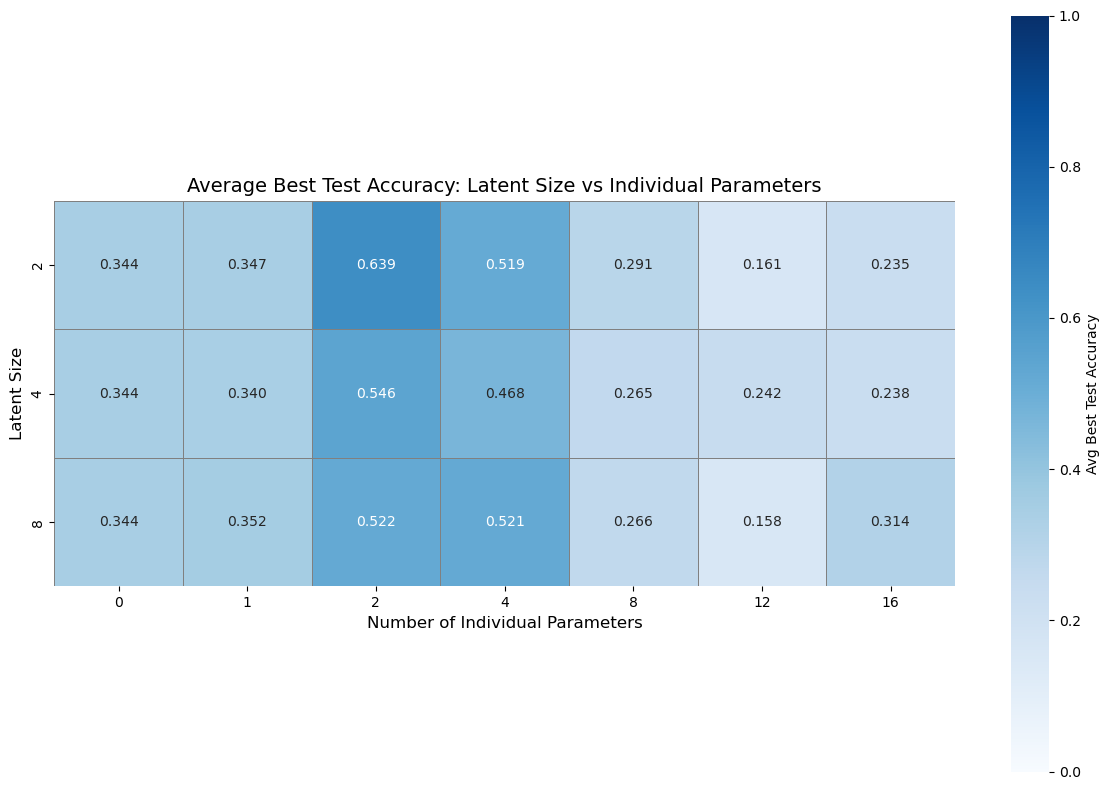

In [1]:
import json
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the experiment summary JSON
summary_path = r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\results_summary\experiment_summary.json"

with open(summary_path, 'r') as f:
    data = json.load(f)

# Extract experiments
experiments = data.get("experiments", [])
print(f"Total experiments: {len(experiments)}")

# Organize data by (latent_size, num_individual_params) -> list of accuracies
data_dict = {}

for exp in experiments:
    latent_size = exp.get("latent_size")
    num_params = exp.get("num_individual_params")
    best_accuracy = exp.get("best_avg_test_accuracy")
    
    if latent_size is not None and num_params is not None and best_accuracy is not None:
        key = (latent_size, num_params)
        if key not in data_dict:
            data_dict[key] = []
        data_dict[key].append(best_accuracy)

print(f"Found {len(data_dict)} unique (latent_size, num_params) combinations")

# Compute averages for each combination
data_for_heatmap = {}
for (latent_size, num_params), accuracies in data_dict.items():
    avg_accuracy = np.mean(accuracies)
    num_seeds = len(accuracies)
    data_for_heatmap[(latent_size, num_params)] = avg_accuracy
    print(f"Latent Size: {latent_size}, Num Params: {num_params} -> Avg Accuracy: {avg_accuracy:.4f} (from {num_seeds} seeds)")

# Extract unique values for axes
latent_sizes = sorted(set(k[0] for k in data_for_heatmap.keys()))
num_params_list = sorted(set(k[1] for k in data_for_heatmap.keys()))

print(f"\nLatent sizes: {latent_sizes}")
print(f"Num params: {num_params_list}")

# Build matrix: rows = latent_size, columns = num_individual_params
matrix = np.full((len(latent_sizes), len(num_params_list)), np.nan)

for i, ls in enumerate(latent_sizes):
    for j, np_val in enumerate(num_params_list):
        if (ls, np_val) in data_for_heatmap:
            matrix[i, j] = data_for_heatmap[(ls, np_val)]

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    matrix,
    annot=True,
    fmt='.3f',
    cmap='Blues',
    xticklabels=num_params_list,
    yticklabels=latent_sizes,
    vmin=0.0,
    vmax=1.0,
    cbar_kws={'label': 'Avg Best Test Accuracy'},
    linewidths=0.5,
    linecolor='gray',
    square=True
)

plt.xlabel('Number of Individual Parameters', fontsize=12)
plt.ylabel('Latent Size', fontsize=12)
plt.title('Average Best Test Accuracy: Latent Size vs Individual Parameters', fontsize=14)
plt.tight_layout()
plt.show()


Loaded: Latent Size: 5, Num Params: 1 -> Accuracy: 0.7836
Loaded: Latent Size: 5, Num Params: 2 -> Accuracy: 0.8436
Loaded: Latent Size: 5, Num Params: 3 -> Accuracy: 0.8364

Found 3 unique (latent_size, num_params) combinations
Latent Size: 5, Num Params: 1 -> Avg Accuracy: 0.7836 (from 1 seeds)
Latent Size: 5, Num Params: 2 -> Avg Accuracy: 0.8436 (from 1 seeds)
Latent Size: 5, Num Params: 3 -> Avg Accuracy: 0.8364 (from 1 seeds)

Latent sizes: [5]
Num params: [1, 2, 3]


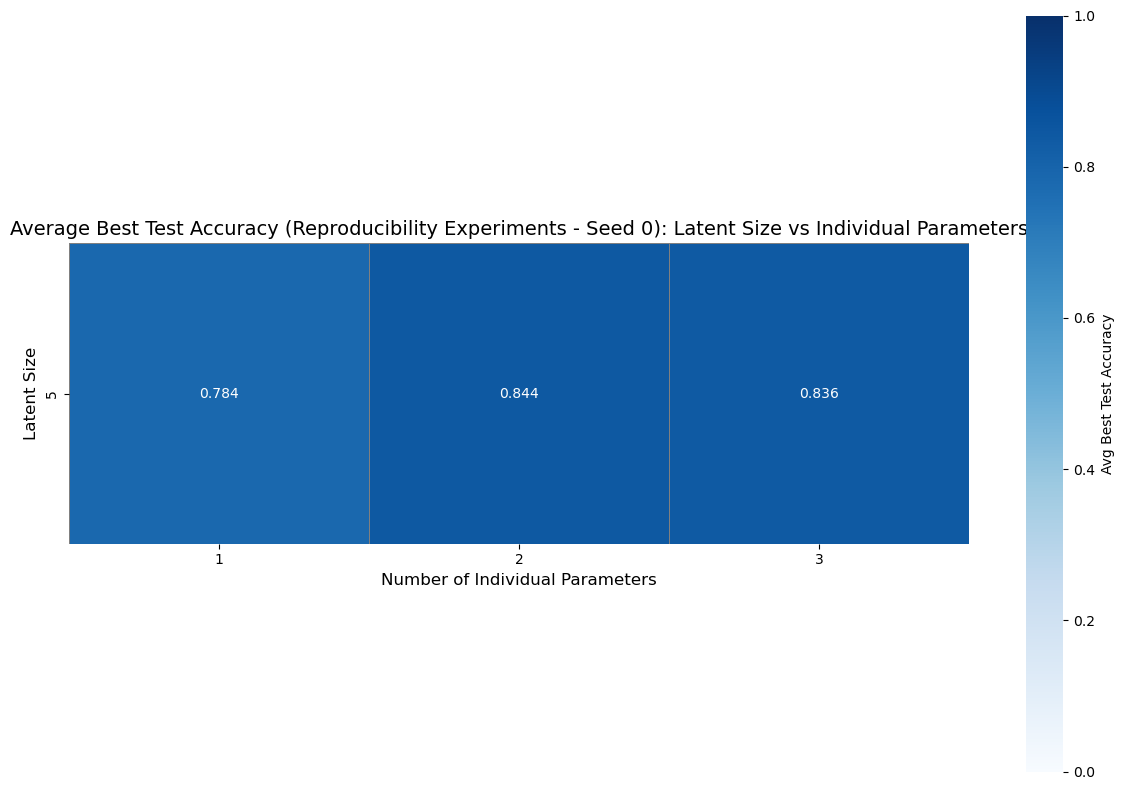

In [5]:
import json
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Load data from reproducibility_experiments/seed_0
base_path = r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\reproducibility_experiments\seed_0"

# Organize data by (latent_size, num_individual_params) -> list of accuracies
data_dict = {}

# Iterate through directories starting with tasks_
base_dir = Path(base_path)
for task_dir in sorted(base_dir.glob("tasks_11*")):
    if not task_dir.is_dir():
        continue
    
    # Load metadata.json
    metadata_path = task_dir / "metadata.json"
    if not metadata_path.exists():
        print(f"Warning: metadata.json not found in {task_dir}")
        continue
    
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    
    # Extract key parameters directly from metadata
    latent_size = metadata.get("latent_size")
    num_params = metadata.get("num_individual_params")
    best_accuracy = metadata.get("best_avg_test_accuracy")
    
    if latent_size is not None and num_params is not None and best_accuracy is not None:
        key = (latent_size, num_params)
        if key not in data_dict:
            data_dict[key] = []
        data_dict[key].append(best_accuracy)
        print(f"Loaded: Latent Size: {latent_size}, Num Params: {num_params} -> Accuracy: {best_accuracy:.4f}")
    else:
        print(f"Warning: Missing data in {task_dir.name}")

print(f"\nFound {len(data_dict)} unique (latent_size, num_params) combinations")

# Compute averages for each combination
data_for_heatmap = {}
for (latent_size, num_params), accuracies in data_dict.items():
    avg_accuracy = np.mean(accuracies)
    num_seeds = len(accuracies)
    data_for_heatmap[(latent_size, num_params)] = avg_accuracy
    print(f"Latent Size: {latent_size}, Num Params: {num_params} -> Avg Accuracy: {avg_accuracy:.4f} (from {num_seeds} seeds)")

# Extract unique values for axes
latent_sizes = sorted(set(k[0] for k in data_for_heatmap.keys()))
num_params_list = sorted(set(k[1] for k in data_for_heatmap.keys()))

print(f"\nLatent sizes: {latent_sizes}")
print(f"Num params: {num_params_list}")

# Build matrix: rows = latent_size, columns = num_individual_params
matrix = np.full((len(latent_sizes), len(num_params_list)), np.nan)

for i, ls in enumerate(latent_sizes):
    for j, np_val in enumerate(num_params_list):
        if (ls, np_val) in data_for_heatmap:
            matrix[i, j] = data_for_heatmap[(ls, np_val)]

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    matrix,
    annot=True,
    fmt='.3f',
    cmap='Blues',
    xticklabels=num_params_list,
    yticklabels=latent_sizes,
    vmin=0.0,
    vmax=1.0,
    cbar_kws={'label': 'Avg Best Test Accuracy'},
    linewidths=0.5,
    linecolor='gray',
    square=True
)

plt.xlabel('Number of Individual Parameters', fontsize=12)
plt.ylabel('Latent Size', fontsize=12)
plt.title('Average Best Test Accuracy (Reproducibility Experiments - Seed 0): Latent Size vs Individual Parameters', fontsize=14)
plt.tight_layout()
plt.show()


Loaded: tasks_11_params_1_latent_5 with 1 params
Loaded: tasks_11_params_2_latent_5 with 2 params
Loaded: tasks_11_params_3_latent_5 with 3 params

Loaded 33 task-parameter combinations

Heatmap data shape: (11, 3)

Heatmap data:
Num Individual Params     1     2     3
Task                                   
DelayPro               1.00  1.00  1.00
DelayAnti              0.60  1.00  1.00
ReactPro               1.00  1.00  1.00
ReactAnti              0.58  1.00  1.00
CatPro                 1.00  1.00  1.00
CatAnti                1.00  1.00  1.00
Match2Sample           0.72  0.62  0.62
NonMatch2Sample        0.66  0.62  0.62
CtxIntMod1             1.00  1.00  1.00
CtxIntMod2             0.98  1.00  1.00
GoNogo                 1.00  1.00  1.00


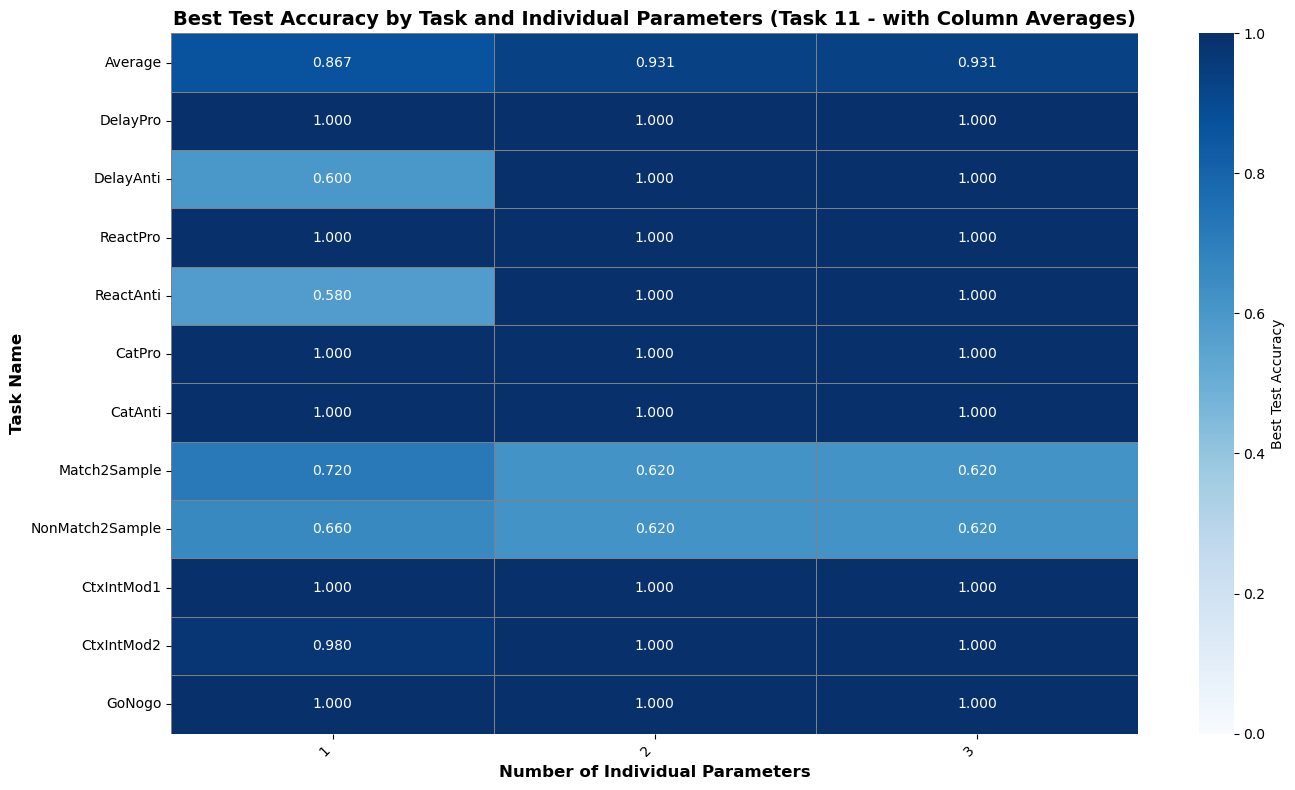


Heatmap generated with 11 tasks and 3 parameter configurations

Column Averages (avg accuracy per parameter config):
Num Individual Params
1    0.867273
2    0.930909
3    0.930909
dtype: float64


In [8]:
import json
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Load data from reproducibility_experiments/seed_0 - TASK 11 ONLY
base_path = r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\reproducibility_experiments\seed_0"

# Organize data: list of dicts with {Task, Num Individual Params, Best Test Accuracy}
all_data = []

# Iterate through directories starting with tasks_11*
base_dir = Path(base_path)
for task_dir in sorted(base_dir.glob("tasks_11*")):
    if not task_dir.is_dir():
        continue
    
    # Load metadata.json
    metadata_path = task_dir / "metadata.json"
    if not metadata_path.exists():
        continue
    
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    
    # Load results.npz
    results_path = task_dir / "results.npz"
    if not results_path.exists():
        continue
    
    results = np.load(results_path, allow_pickle=True)
    
    # Extract key parameters
    num_params = metadata.get("num_individual_params")
    task_names = metadata.get("task_names", [])
    
    # Extract per-task accuracies from test_task_accuracies
    test_task_accs = results['test_task_accuracies'].item() if 'test_task_accuracies' in results.files else {}
    
    if num_params is not None and test_task_accs:
        # For each task, get the best accuracy across all epochs
        for task_idx, task_name in enumerate(task_names):
            if task_idx in test_task_accs:
                accs = test_task_accs[task_idx]
                best_acc = float(np.max(accs)) if isinstance(accs, (list, np.ndarray)) else float(accs)
                
                all_data.append({
                    'Task': task_name,
                    'Num Individual Params': num_params,
                    'Best Test Accuracy': best_acc
                })
        
        print(f"Loaded: {task_dir.name} with {num_params} params")
    
    results.close()

print(f"\nLoaded {len(all_data)} task-parameter combinations")

# Create DataFrame from task data
df = pd.DataFrame(all_data)

# Pivot data for heatmap: tasks as rows, num_params as columns
heatmap_pivot = df.pivot_table(
    index='Task',
    columns='Num Individual Params',
    values='Best Test Accuracy',
    aggfunc='mean'
)

# Sort columns for better visualization
heatmap_pivot = heatmap_pivot.sort_index(axis=1)

# Reorder rows to task order if available
task_order = ["DelayPro", "DelayAnti", "ReactPro", "ReactAnti", "CatPro", "CatAnti", 
              "Match2Sample", "NonMatch2Sample", "CtxIntMod1", "CtxIntMod2", "GoNogo"]
available_tasks = [task for task in task_order if task in heatmap_pivot.index]
heatmap_pivot = heatmap_pivot.loc[available_tasks]

print("\nHeatmap data shape:", heatmap_pivot.shape)
print("\nHeatmap data:")
print(heatmap_pivot)

# Compute column averages (average accuracy for each parameter configuration)
col_averages = heatmap_pivot.mean(axis=0)

# Add column averages as a row at the top
heatmap_with_avg = pd.concat([
    pd.DataFrame([col_averages], index=['Average']),
    heatmap_pivot
])

# Create heatmap
fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(
    heatmap_with_avg,
    annot=True,  # Show values in cells
    fmt='.3f',   # 3 decimal places
    cmap='Blues',  # Blue colormap
    cbar_kws={'label': 'Best Test Accuracy'},
    ax=ax,
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor='gray'
)

ax.set_xlabel('Number of Individual Parameters', fontsize=12, fontweight='bold')
ax.set_ylabel('Task Name', fontsize=12, fontweight='bold')
ax.set_title('Best Test Accuracy by Task and Individual Parameters (Task 11 - with Column Averages)', fontsize=14, fontweight='bold')

# Set y-axis ticks to show all parameter values
ax.set_yticks(np.arange(0.5, len(heatmap_with_avg), 1))
ax.set_yticklabels(heatmap_with_avg.index)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nHeatmap generated with {heatmap_pivot.shape[0]} tasks and {heatmap_pivot.shape[1]} parameter configurations")
print("\nColumn Averages (avg accuracy per parameter config):")
print(col_averages)


In [1]:
import numpy as np
import torch

model_4 = torch.load(r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\experiment_results\tasks_11_params_4\model.pt")

In [ ]:
model_4["p_vector"]
p2W = model_4["p2W"]
model_4 = torch.load(r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\experiment_results\tasks_11_params_4\model.pt")

torch.Size([11, 4])

In [3]:
p2W = model_4["p2W"]

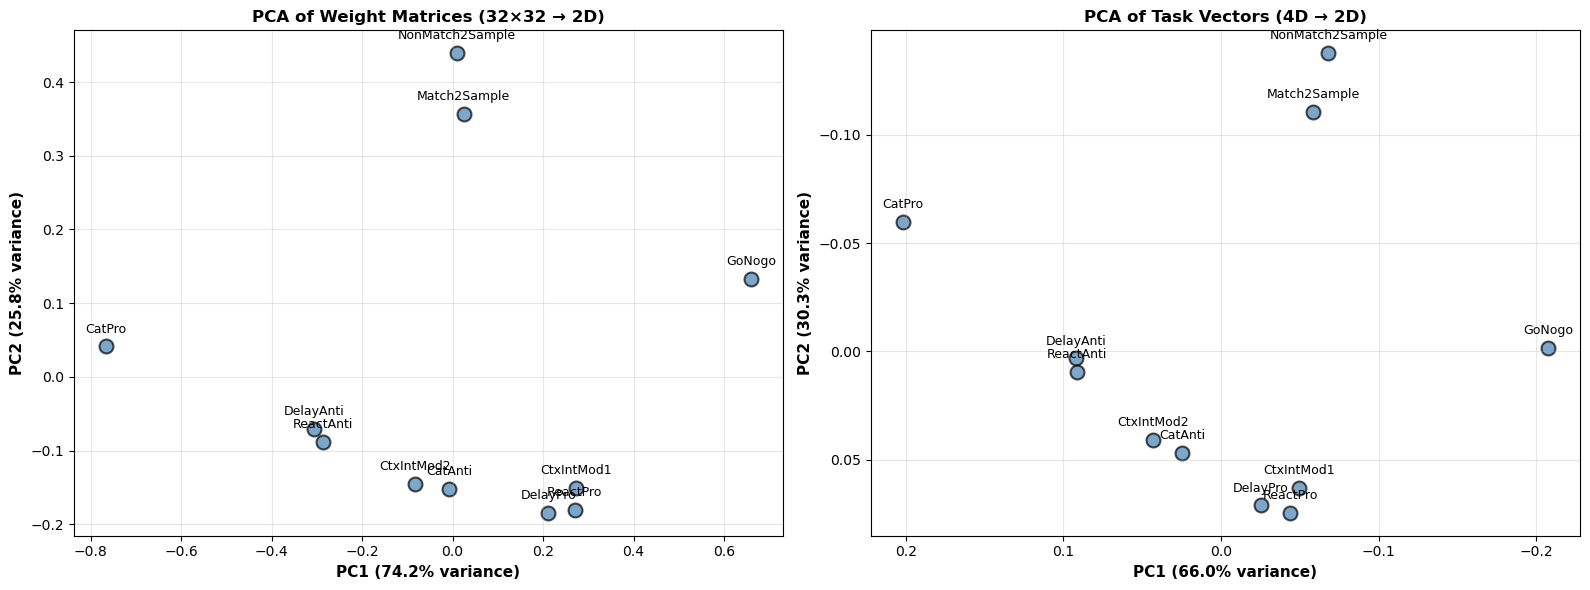

Weight Matrices - Total variance explained: 99.99%
Task Vectors - Total variance explained: 96.33%


In [17]:
import numpy as np
from sklearn.decomposition import PCA
import torch
import matplotlib.pyplot as plt

# Task order
task_order = ["DelayPro", "DelayAnti", "ReactPro", "ReactAnti", "CatPro", "CatAnti", 
              "Match2Sample", "NonMatch2Sample", "CtxIntMod1", "CtxIntMod2", "GoNogo"]

# Left plot: PCA of Weight Matrices
W_matrices = torch.einsum("bd,dij->bij", model_4["p_vector"], model_4["p2W"])
W_flattened = W_matrices.cpu().detach().numpy().reshape(W_matrices.shape[0], -1)

pca_W = PCA(n_components=2)
W_pca = pca_W.fit_transform(W_flattened)

# Right plot: PCA of Task Vectors
task_vectors = model_4["p_vector"].cpu().detach().numpy() if isinstance(model_4["p_vector"], torch.Tensor) else model_4["p_vector"]
pca_task = PCA(n_components=2)
task_vectors_pca = pca_task.fit_transform(task_vectors)

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Weight Matrices PCA
axes[0].scatter(W_pca[:, 0], W_pca[:, 1], s=100, alpha=0.7, color='steelblue', 
                edgecolors='black', linewidth=1.5)
for i, task in enumerate(task_order):
    axes[0].annotate(task, (W_pca[i, 0], W_pca[i, 1]), 
                    textcoords="offset points", xytext=(0, 10), 
                    ha='center', fontsize=9)
axes[0].set_xlabel(f'PC1 ({pca_W.explained_variance_ratio_[0]:.1%} variance)', fontsize=11, fontweight='bold')
axes[0].set_ylabel(f'PC2 ({pca_W.explained_variance_ratio_[1]:.1%} variance)', fontsize=11, fontweight='bold')
axes[0].set_title('PCA of Weight Matrices (32×32 → 2D)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Right plot: Task Vectors PCA
axes[1].scatter(task_vectors_pca[:, 0], task_vectors_pca[:, 1], s=100, alpha=0.7, color='steelblue', 
                edgecolors='black', linewidth=1.5)
for i, task in enumerate(task_order):
    axes[1].annotate(task, (task_vectors_pca[i, 0], task_vectors_pca[i, 1]), 
                    textcoords="offset points", xytext=(0, 10), 
                    ha='center', fontsize=9)
axes[1].set_xlabel(f'PC1 ({pca_task.explained_variance_ratio_[0]:.1%} variance)', fontsize=11, fontweight='bold')
axes[1].set_ylabel(f'PC2 ({pca_task.explained_variance_ratio_[1]:.1%} variance)', fontsize=11, fontweight='bold')
axes[1].set_title('PCA of Task Vectors (4D → 2D)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].invert_yaxis()
axes[1].invert_xaxis()
plt.tight_layout()
plt.show()

print(f"Weight Matrices - Total variance explained: {sum(pca_W.explained_variance_ratio_):.2%}")
print(f"Task Vectors - Total variance explained: {sum(pca_task.explained_variance_ratio_):.2%}")

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Your 4D data
# Assuming task_vectors is your data (n_tasks × 4 features)
# and task_order contains the task names

# Example data - replace with your actual data
task_vectors = model_4["p_vector"]  # 10 tasks, 4 features each
task_order = ["DelayPro", "DelayAnti", "ReactPro", "ReactAnti", "CatPro", "CatAnti", 
              "Match2Sample", "NonMatch2Sample", "CtxIntMod1", "CtxIntMod2", "GoNogo"]

# Run PCA to reduce to 2D
pca = PCA(n_components=2)
task_vectors_pca = pca.fit_transform(task_vectors)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

# Create scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(task_vectors_pca[:, 0], task_vectors_pca[:, 1], 
            s=100, alpha=0.7, color='steelblue', 
            edgecolors='black', linewidth=1.5)

# Add task labels
for i, task in enumerate(task_order):
    plt.annotate(task, 
                (task_vectors_pca[i, 0], task_vectors_pca[i, 1]), 
                textcoords="offset points", 
                xytext=(0, 10), 
                ha='center', 
                fontsize=9)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', 
          fontsize=12, fontweight='bold')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', 
          fontsize=12, fontweight='bold')
plt.title('PCA of Task Vectors (4D → 2D)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [2]:
import torch
from pathlib import Path
import re

# Path to experiment results
base_path = r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\experiment_results"

# Define the parameter order
param_order = [1, 2, 4, 8, 11, 12, 16]

# List to store all p_vectors (in order by num_individual_params)
p_vector_list = []
experiment_info = []

# Iterate through all subdirectories and sort by parameter order
base_dir = Path(base_path)
all_exp_dirs = list(base_dir.glob("tasks_*"))

# Extract num_individual_params from directory name and sort accordingly
def get_num_params(exp_dir):
    """Extract num_individual_params from directory name"""
    match = re.search(r'params_(\d+)', exp_dir.name)
    if match:
        return int(match.group(1))
    return float('inf')  # Put unmatchable ones at the end

# Sort directories by the param_order list
sorted_exp_dirs = sorted(all_exp_dirs, key=lambda x: (param_order.index(get_num_params(x)) if get_num_params(x) in param_order else len(param_order), x.name))

for exp_dir in sorted_exp_dirs:
    if not exp_dir.is_dir():
        continue
    
    # Path to model
    model_path = exp_dir / "model.pt"
    
    if not model_path.exists():
        print(f"Warning: model.pt not found in {exp_dir.name}")
        continue
    
    try:
        # Load model
        model = torch.load(model_path)
        
        # Extract p_vector if it exists
        if "p_vector" in model:
            p_vec = model["p_vector"]
            p_vector_list.append(p_vec)
            
            # Store experiment info
            num_params = get_num_params(exp_dir)
            experiment_info.append({
                'experiment': exp_dir.name,
                'num_params': num_params,
                'p_vector_shape': p_vec.shape if hasattr(p_vec, 'shape') else len(p_vec),
                'p_vector_dtype': str(p_vec.dtype) if hasattr(p_vec, 'dtype') else type(p_vec)
            })
            
            print(f"Loaded p_vector from {exp_dir.name}, shape: {p_vec.shape if hasattr(p_vec, 'shape') else len(p_vec)}")
        else:
            print(f"Warning: p_vector not found in {exp_dir.name}")
    
    except Exception as e:
        print(f"Error loading model from {exp_dir.name}: {e}")

print(f"\nTotal p_vectors loaded: {len(p_vector_list)}")
print(f"\nExperiment info (ordered by params [1, 2, 4, 8, 11, 12, 16]):")
for i, info in enumerate(experiment_info):
    print(f"  [{i}] params={info['num_params']:2d} - {info['experiment']} - shape: {info['p_vector_shape']}")


Loaded p_vector from tasks_11_params_1, shape: torch.Size([11, 1])
Loaded p_vector from tasks_11_params_2, shape: torch.Size([11, 2])
Loaded p_vector from tasks_11_params_4, shape: torch.Size([11, 4])
Loaded p_vector from tasks_11_params_8, shape: torch.Size([11, 8])
Loaded p_vector from tasks_11_params_11, shape: torch.Size([11, 11])
Loaded p_vector from tasks_11_params_12, shape: torch.Size([11, 12])
Loaded p_vector from tasks_11_params_16, shape: torch.Size([11, 16])

Total p_vectors loaded: 7

Experiment info (ordered by params [1, 2, 4, 8, 11, 12, 16]):
  [0] params= 1 - tasks_11_params_1 - shape: torch.Size([11, 1])
  [1] params= 2 - tasks_11_params_2 - shape: torch.Size([11, 2])
  [2] params= 4 - tasks_11_params_4 - shape: torch.Size([11, 4])
  [3] params= 8 - tasks_11_params_8 - shape: torch.Size([11, 8])
  [4] params=11 - tasks_11_params_11 - shape: torch.Size([11, 11])
  [5] params=12 - tasks_11_params_12 - shape: torch.Size([11, 12])
  [6] params=16 - tasks_11_params_16 - sh

p_vec[0] shape: torch.Size([11, 4])
Number of tasks: 11
✓ Dimensions match: 11 tasks

p_vec[0] numpy shape: (11, 4)
p_vec[0] first 3 elements: [[-0.10084227  0.8285143  -1.123368   -0.9480653 ]
 [ 0.03989001  0.8160632  -1.103528   -0.97310627]
 [-0.11649876  0.83530784 -1.0964965  -0.9588336 ]]

Parameter Vector per Task:
               Task                                   Parameter Vector
0          DelayPro    [-0.10084227, 0.8285143, -1.123368, -0.9480653]
1         DelayAnti   [0.039890006, 0.8160632, -1.103528, -0.97310627]
2          ReactPro  [-0.11649876, 0.83530784, -1.0964965, -0.9588336]
3         ReactAnti    [0.03416401, 0.8162604, -1.1205001, -0.9640391]
4            CatPro    [0.16430122, 0.81914353, -1.109321, -0.9505466]
5           CatAnti  [-0.041635714, 0.8196763, -1.1132346, -0.97333...
6      Match2Sample  [-0.046747513, 0.71387357, -1.0212833, -0.8599...
7   NonMatch2Sample  [-0.04181016, 0.6924135, -1.0009038, -0.85429674]
8        CtxIntMod1   [-0.11721848, 

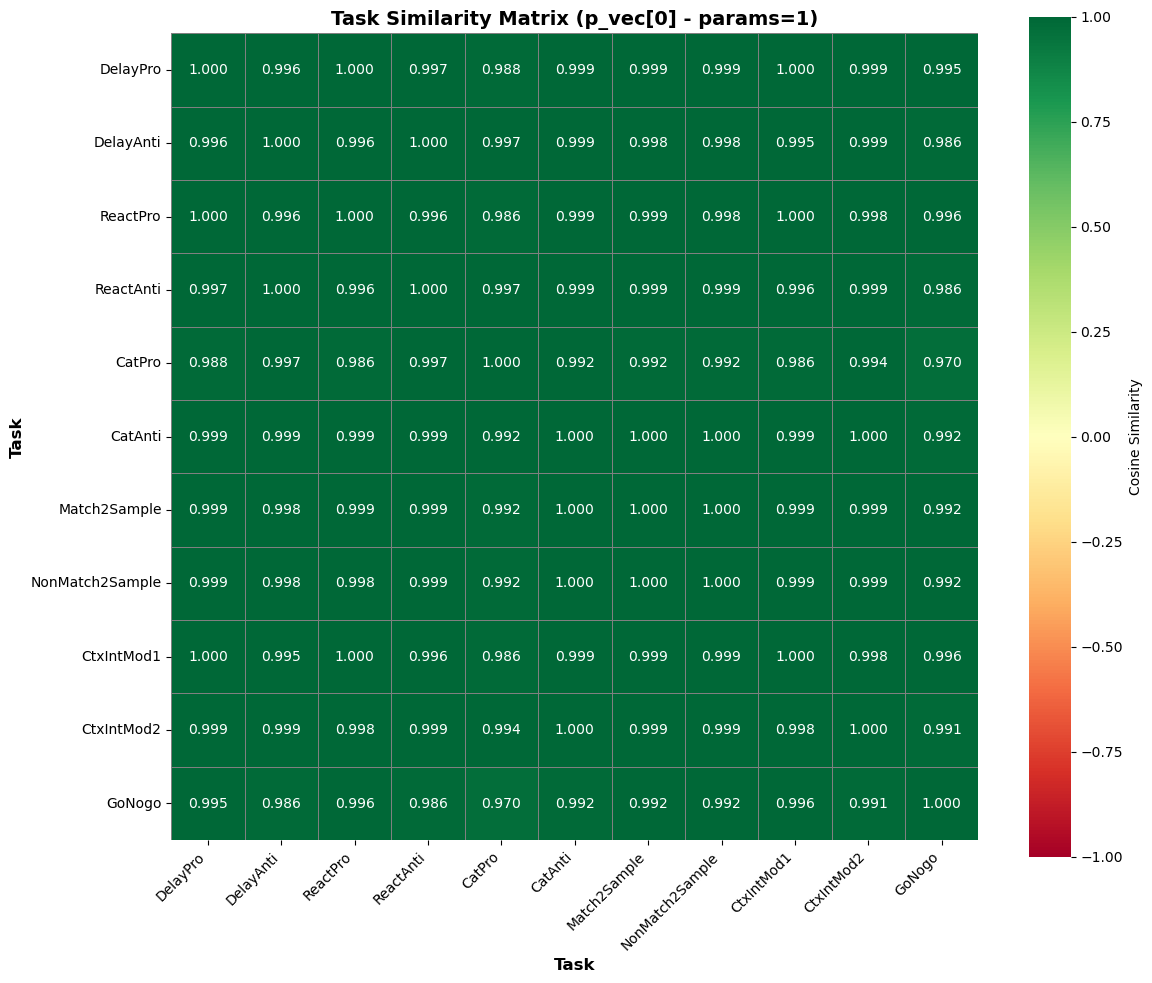


Most similar task pairs:
  Match2Sample         <-> NonMatch2Sample     : 1.0000
  DelayAnti            <-> ReactAnti           : 0.9999
  CatAnti              <-> CtxIntMod2          : 0.9999
  DelayPro             <-> ReactPro            : 0.9998
  DelayPro             <-> CtxIntMod1          : 0.9998
  CatAnti              <-> Match2Sample        : 0.9997
  CatAnti              <-> NonMatch2Sample     : 0.9997
  ReactPro             <-> CtxIntMod1          : 0.9996
  NonMatch2Sample      <-> CtxIntMod2          : 0.9994
  Match2Sample         <-> CtxIntMod2          : 0.9993


In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr

# Task order
task_order = ["DelayPro", "DelayAnti", "ReactPro", "ReactAnti", "CatPro", "CatAnti", 
              "Match2Sample", "NonMatch2Sample", "CtxIntMod1", "CtxIntMod2", "GoNogo"]

# Extract p_vec[0] (first parameter vector, corresponding to params=1)
p_vec_0 = model_4["p_vector"]

print(f"p_vec[0] shape: {p_vec_0.shape}")
print(f"Number of tasks: {len(task_order)}")

# Check if dimensions match
if p_vec_0.shape[0] != len(task_order):
    print(f"Warning: p_vec[0] has {p_vec_0.shape[0]} elements but {len(task_order)} tasks")
else:
    print(f"✓ Dimensions match: {p_vec_0.shape[0]} tasks")

# Convert to numpy array if needed
if isinstance(p_vec_0, torch.Tensor):
    p_vec_0_np = p_vec_0.cpu().detach().numpy()
else:
    p_vec_0_np = np.array(p_vec_0)

print(f"\np_vec[0] numpy shape: {p_vec_0_np.shape}")
print(f"p_vec[0] first 3 elements: {p_vec_0_np[:3]}")

# Create a DataFrame for easy viewing
df_pvec = pd.DataFrame({
    'Task': task_order,
    'Parameter Vector': [p_vec_0_np[i] for i in range(len(task_order))]
})

print("\nParameter Vector per Task:")
print(df_pvec)

# Compute task similarity using cosine similarity
# Flatten each task's parameter vector for similarity computation
if len(p_vec_0_np.shape) == 1:
    # If p_vec_0 is 1D, treat each element as a task vector of size 1
    task_vectors = p_vec_0_np.reshape(-1, 1)
else:
    # If p_vec_0 is 2D, each row is a task vector
    task_vectors = p_vec_0_np

print(f"\nTask vectors shape: {task_vectors.shape}")

# Compute cosine similarity matrix
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(task_vectors)

# Create similarity heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    xticklabels=task_order,
    yticklabels=task_order,
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Cosine Similarity'},
    square=True,
    linewidths=0.5,
    linecolor='gray'
)

plt.xlabel('Task', fontsize=12, fontweight='bold')
plt.ylabel('Task', fontsize=12, fontweight='bold')
plt.title('Task Similarity Matrix (p_vec[0] - params=1)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Find most similar task pairs
similarity_df = pd.DataFrame(similarity_matrix, index=task_order, columns=task_order)

print("\nMost similar task pairs:")
similarities = []
for i in range(len(task_order)):
    for j in range(i+1, len(task_order)):
        similarities.append({
            'Task 1': task_order[i],
            'Task 2': task_order[j],
            'Similarity': similarity_matrix[i, j]
        })

similarities_sorted = sorted(similarities, key=lambda x: x['Similarity'], reverse=True)
for sim in similarities_sorted[:10]:
    print(f"  {sim['Task 1']:20s} <-> {sim['Task 2']:20s}: {sim['Similarity']:.4f}")


In [1]:
import json
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Base path for second experiment
base_path = r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\results_cluster\second_experiment\second_experiment"

# Task order
task_order = ["DelayPro", "DelayAnti", "ReactPro", "ReactAnti", "CatPro", "CatAnti", 
              "Match2Sample", "NonMatch2Sample", "CtxIntMod1", "CtxIntMod2", "GoNogo"]

def load_experiment_data(hidden_size_folder):
    """Load data from a specific hidden size folder (hidden_32 or hidden_64)"""
    # Organize data: list of dicts with {Task, Num Individual Params, Best Test Accuracy, Seed}
    all_data = []
    
    hidden_path = Path(base_path) / hidden_size_folder
    
    if not hidden_path.exists():
        print(f"Warning: {hidden_path} does not exist")
        return pd.DataFrame()
    
    # Iterate through seed directories
    for seed_dir in sorted(hidden_path.glob("seed_*")):
        if not seed_dir.is_dir():
            continue
        
        seed_num = seed_dir.name.split('_')[-1]
        
        # Iterate through task directories
        for task_dir in sorted(seed_dir.glob("tasks_*")):
            if not task_dir.is_dir():
                continue
            
            # Load metadata.json
            metadata_path = task_dir / "metadata.json"
            if not metadata_path.exists():
                continue
            
            with open(metadata_path, 'r') as f:
                metadata = json.load(f)
            
            # Extract parameters
            num_params = metadata.get("num_individual_params")
            task_names = metadata.get("task_names", [])
            
            # Get per-task accuracies
            if "test_task_accuracies" in metadata:
                test_task_accs = metadata["test_task_accuracies"]
                
                if num_params is not None and test_task_accs:
                    # For each task, get the best accuracy
                    for task_idx, task_name in enumerate(task_names):
                        if str(task_idx) in test_task_accs:
                            accs = test_task_accs[str(task_idx)]
                            best_acc = float(max(accs)) if isinstance(accs, list) else float(accs)
                            
                            all_data.append({
                                'Task': task_name,
                                'Num Individual Params': num_params,
                                'Best Test Accuracy': best_acc,
                                'Seed': seed_num
                            })
            
            print(f"Loaded: {hidden_size_folder}/{seed_dir.name}/{task_dir.name}")
    
    return pd.DataFrame(all_data)

# Load data for both hidden sizes
df_32 = load_experiment_data("hidden_32")
df_64 = load_experiment_data("hidden_64")

print(f"\nHidden 32: Loaded {len(df_32)} task-parameter-seed combinations")
print(f"Hidden 64: Loaded {len(df_64)} task-parameter-seed combinations")

# Function to create heatmap with averages
def create_heatmap(df, hidden_size):
    if df.empty:
        print(f"No data for {hidden_size}")
        return
    
    # Average across seeds
    df_avg = df.groupby(['Task', 'Num Individual Params'])['Best Test Accuracy'].mean().reset_index()
    
    # Pivot data for heatmap
    heatmap_pivot = df_avg.pivot_table(
        index='Task',
        columns='Num Individual Params',
        values='Best Test Accuracy',
        aggfunc='mean'
    )
    
    # Sort columns
    heatmap_pivot = heatmap_pivot.sort_index(axis=1)
    
    # Reorder rows to task order
    available_tasks = [task for task in task_order if task in heatmap_pivot.index]
    heatmap_pivot = heatmap_pivot.loc[available_tasks]
    
    # Compute column averages
    col_averages = heatmap_pivot.mean(axis=0)
    
    # Add column averages as a row at the top
    heatmap_with_avg = pd.concat([
        pd.DataFrame([col_averages], index=['Average']),
        heatmap_pivot
    ])
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(14, 8))
    
    sns.heatmap(
        heatmap_with_avg,
        annot=True,
        fmt='.3f',
        cmap='Blues',
        cbar_kws={'label': 'Best Test Accuracy'},
        ax=ax,
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor='gray'
    )
    
    ax.set_xlabel('Number of Individual Parameters', fontsize=12, fontweight='bold')
    ax.set_ylabel('Task Name', fontsize=12, fontweight='bold')
    ax.set_title(f'Best Test Accuracy by Task and Individual Parameters ({hidden_size} - Averaged Across Seeds)', 
                 fontsize=14, fontweight='bold')
    
    ax.set_yticks(np.arange(0.5, len(heatmap_with_avg), 1))
    ax.set_yticklabels(heatmap_with_avg.index)
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    print(f"\n{hidden_size} - Heatmap generated with {heatmap_pivot.shape[0]} tasks and {heatmap_pivot.shape[1]} parameter configurations")
    print(f"\n{hidden_size} - Column Averages (avg accuracy per parameter config):")
    print(col_averages)
    print(f"\n{hidden_size} - Seeds used: {sorted(df['Seed'].unique())}")

# Create heatmaps for both hidden sizes
create_heatmap(df_32, "Hidden Size 32")
create_heatmap(df_64, "Hidden Size 64")

Loaded: hidden_32/seed_0/tasks_11_params_11_nonlinear_1
Loaded: hidden_32/seed_0/tasks_11_params_11_nonlinear_16
Loaded: hidden_32/seed_0/tasks_11_params_11_nonlinear_2
Loaded: hidden_32/seed_0/tasks_11_params_11_nonlinear_3
Loaded: hidden_32/seed_0/tasks_11_params_11_nonlinear_4
Loaded: hidden_32/seed_0/tasks_11_params_11_nonlinear_5
Loaded: hidden_32/seed_0/tasks_11_params_11_nonlinear_6
Loaded: hidden_32/seed_0/tasks_11_params_11_nonlinear_8
Loaded: hidden_32/seed_0/tasks_11_params_12_nonlinear_1
Loaded: hidden_32/seed_0/tasks_11_params_12_nonlinear_16
Loaded: hidden_32/seed_0/tasks_11_params_12_nonlinear_2
Loaded: hidden_32/seed_0/tasks_11_params_12_nonlinear_3
Loaded: hidden_32/seed_0/tasks_11_params_12_nonlinear_4
Loaded: hidden_32/seed_0/tasks_11_params_12_nonlinear_5
Loaded: hidden_32/seed_0/tasks_11_params_12_nonlinear_6
Loaded: hidden_32/seed_0/tasks_11_params_12_nonlinear_8
Loaded: hidden_32/seed_0/tasks_11_params_1_nonlinear_1
Loaded: hidden_32/seed_0/tasks_11_params_1_nonl

Loading hidden_32...
Hidden 32: Loaded 177 experiments

Loading hidden_64...
Hidden 64: Loaded 130 experiments

Hidden Size 32 - Best combination:
  Nonlinear Units: 16
  Num Individual Params: 2
  Best Avg Test Accuracy: 0.8745

Hidden Size 64 - Best combination:
  Nonlinear Units: 16
  Num Individual Params: 4
  Best Avg Test Accuracy: 0.9418


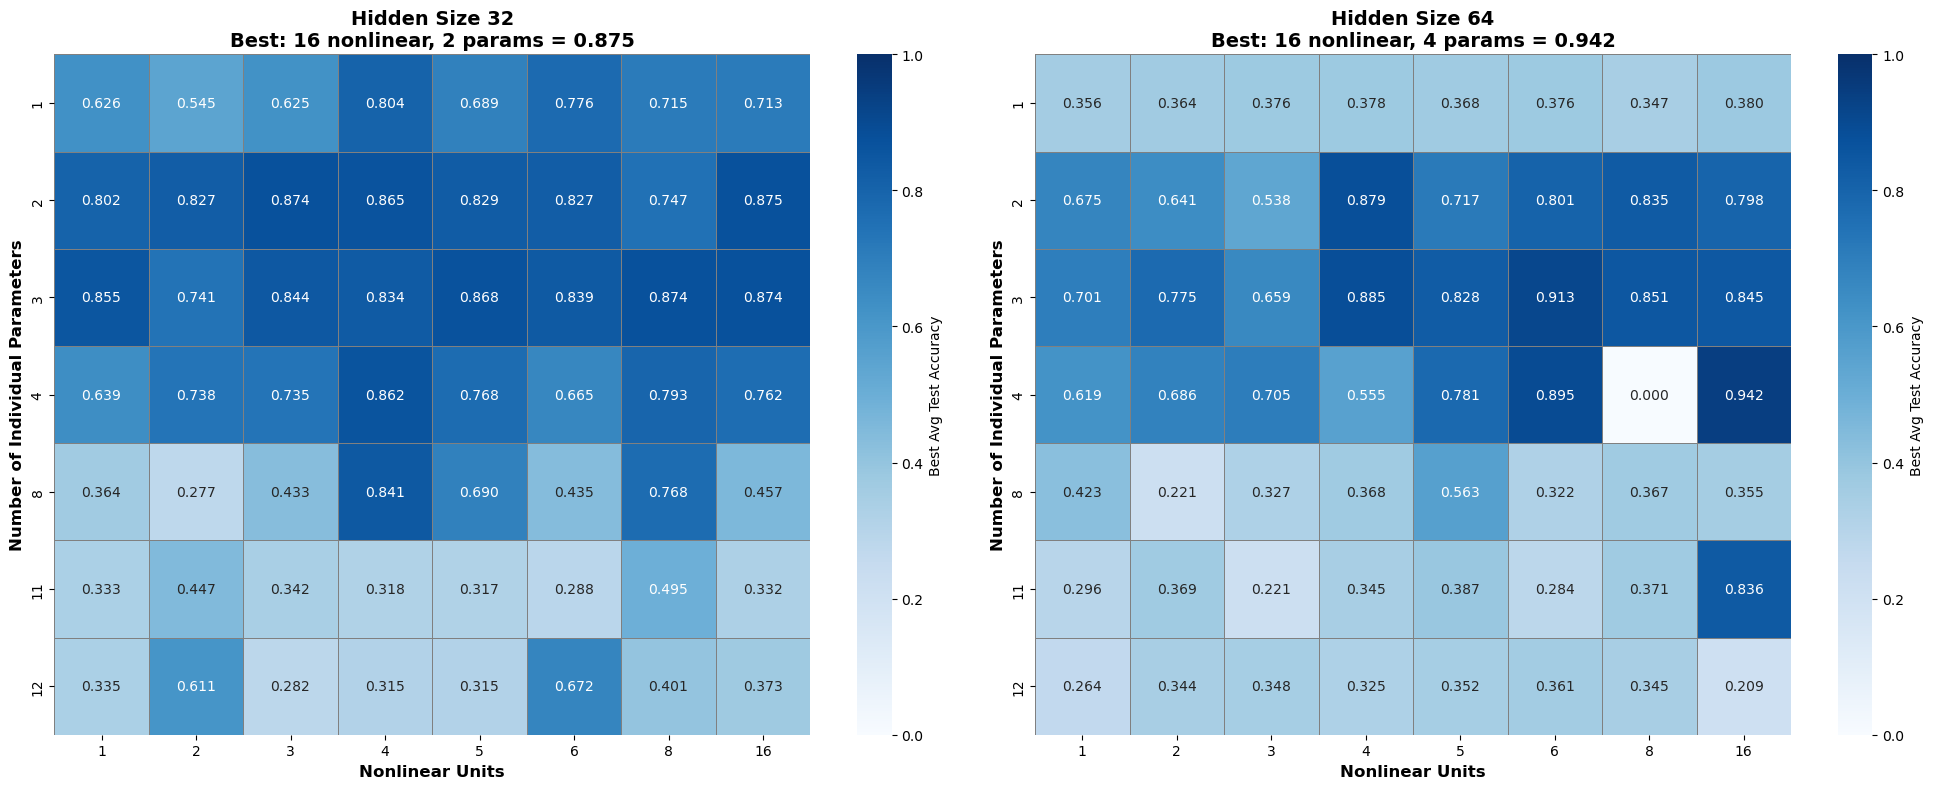

In [41]:
import json
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import re

# Base path for second experiment
base_path = r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\results_cluster\second_experiment\second_experiment"

def load_experiment_data(hidden_size_folder):
    """Load data from a specific hidden size folder (hidden_32 or hidden_64)"""
    all_data = []
    
    hidden_path = Path(base_path) / hidden_size_folder
    
    if not hidden_path.exists():
        print(f"Warning: {hidden_path} does not exist")
        return pd.DataFrame()
    
    # Iterate through seed directories
    for seed_dir in sorted(hidden_path.glob("seed_*")):
        if not seed_dir.is_dir():
            continue
        
        seed_num = seed_dir.name.split('_')[-1]
        
        # Look for task directories with pattern: tasks_11_params_X_nonlinear_Y
        for task_dir in sorted(seed_dir.glob("tasks_*_params_*")):
            if not task_dir.is_dir():
                continue
            
            # Extract num_params from directory name
            match = re.search(r'params_(\d+)', task_dir.name)
            if not match:
                continue
            
            num_params = int(match.group(1))
            
            # Load metadata.json
            metadata_path = task_dir / "metadata.json"
            if not metadata_path.exists():
                continue
            
            with open(metadata_path, 'r') as f:
                metadata = json.load(f)
            
            # Get best_avg_test_accuracy and nonlinear_units
            best_avg_acc = metadata.get("best_avg_test_accuracy")
            nonlinear_units = metadata.get("nonlinear_units")
            
            if best_avg_acc is not None and nonlinear_units is not None:
                all_data.append({
                    'Num Individual Params': num_params,
                    'Nonlinear Units': nonlinear_units,
                    'Best Avg Test Accuracy': best_avg_acc,
                    'Seed': seed_num
                })
    
    return pd.DataFrame(all_data)

# Load data for both hidden sizes
print("Loading hidden_32...")
df_32 = load_experiment_data("hidden_32")
print(f"Hidden 32: Loaded {len(df_32)} experiments")

print("\nLoading hidden_64...")
df_64 = load_experiment_data("hidden_64")
print(f"Hidden 64: Loaded {len(df_64)} experiments")

# Function to create side-by-side heatmaps
def create_side_by_side_heatmaps(df_32, df_64):
    # Create figure with 2 subplots side by side
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    datasets = [(df_32, "Hidden Size 32", axes[0]), (df_64, "Hidden Size 64", axes[1])]
    
    for df, hidden_size, ax in datasets:
        if df.empty:
            print(f"No data for {hidden_size}")
            continue
        
        # Average across seeds for each (num_params, nonlinear_units) combination
        df_avg = df.groupby(['Num Individual Params', 'Nonlinear Units'])['Best Avg Test Accuracy'].mean().reset_index()
        
        # Pivot data for heatmap: rows = num_params, columns = nonlinear_units
        heatmap_pivot = df_avg.pivot_table(
            index='Num Individual Params',
            columns='Nonlinear Units',
            values='Best Avg Test Accuracy',
            aggfunc='mean'
        )
        
        # Sort indices
        heatmap_pivot = heatmap_pivot.sort_index(axis=0)  # Sort rows (num params)
        heatmap_pivot = heatmap_pivot.sort_index(axis=1)  # Sort columns (nonlinear units)
        
        # Find the combination with highest accuracy
        max_idx = heatmap_pivot.stack().idxmax()
        max_params, max_nonlinear = max_idx
        max_accuracy = heatmap_pivot.loc[max_params, max_nonlinear]
        
        print(f"\n{hidden_size} - Best combination:")
        print(f"  Nonlinear Units: {max_nonlinear}")
        print(f"  Num Individual Params: {max_params}")
        print(f"  Best Avg Test Accuracy: {max_accuracy:.4f}")
        
        # Create heatmap
        sns.heatmap(
            heatmap_pivot,
            annot=True,
            fmt='.3f',
            cmap='Blues',
            cbar_kws={'label': 'Best Avg Test Accuracy'},
            ax=ax,
            vmin=0.0,
            vmax=1.0,
            linewidths=0.5,
            linecolor='gray'
        )
        
        ax.set_xlabel('Nonlinear Units', fontsize=12, fontweight='bold')
        ax.set_ylabel('Number of Individual Parameters', fontsize=12, fontweight='bold')
        ax.set_title(f'{hidden_size}\nBest: {max_nonlinear} nonlinear, {max_params} params = {max_accuracy:.3f}', 
                     fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Create side-by-side heatmaps
create_side_by_side_heatmaps(df_32, df_64)


Loading hidden_32...
Hidden 32: Loaded 62 experiments

Loading hidden_64...
Hidden 64: Loaded 86 experiments

Hidden Size 32 - Best combination:
  Nonlinear Units: 2
  Num Individual Params: 2
  Best Avg Test Accuracy: 0.9382

Hidden Size 64 - Best combination:
  Nonlinear Units: 4
  Num Individual Params: 3
  Best Avg Test Accuracy: 0.9009


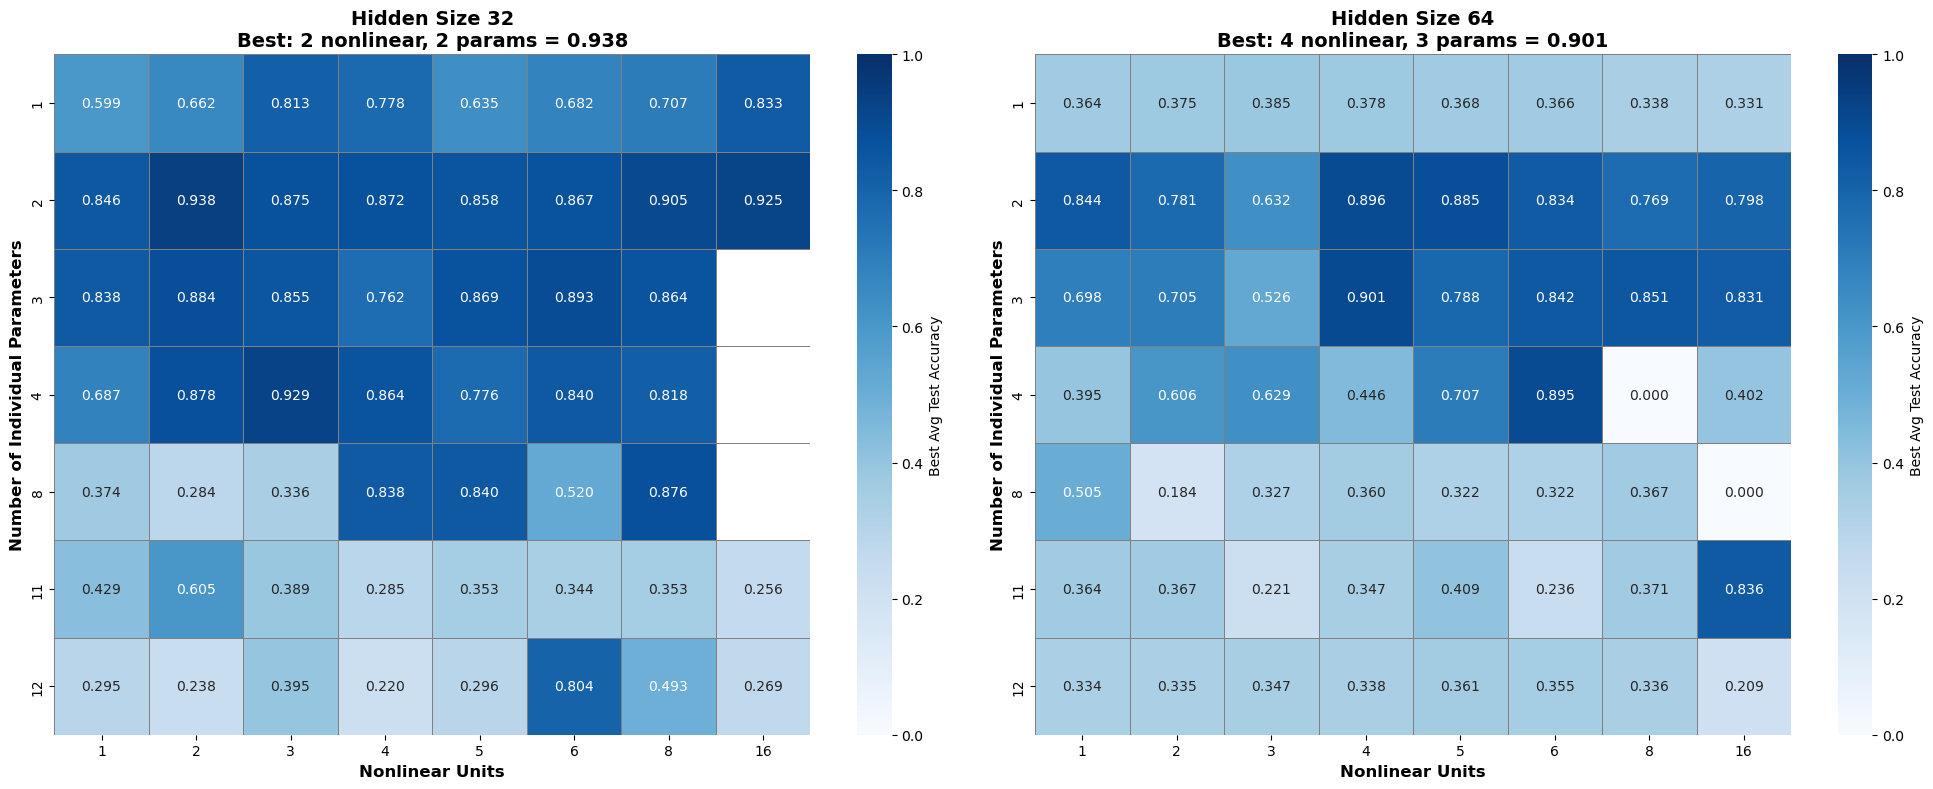

In [5]:
import json
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import re

# Base path for second experiment
base_path = r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\results_cluster\second_experiment\second_experiment"

def load_experiment_data(hidden_size_folder):
    """Load data from a specific hidden size folder (hidden_32 or hidden_64)"""
    all_data = []
    
    hidden_path = Path(base_path) / hidden_size_folder
    
    if not hidden_path.exists():
        print(f"Warning: {hidden_path} does not exist")
        return pd.DataFrame()
    
    # Iterate through seed directories
    for seed_dir in sorted(hidden_path.glob("seed_*")):
        if not seed_dir.is_dir():
            continue
        
        seed_num = seed_dir.name.split('_')[-1]
        
        # Look for task directories with pattern: tasks_11_params_X_nonlinear_Y
        for task_dir in sorted(seed_dir.glob("tasks_*_params_*")):
            if not task_dir.is_dir():
                continue
            
            # Extract num_params from directory name
            match = re.search(r'params_(\d+)', task_dir.name)
            if not match:
                continue
            
            num_params = int(match.group(1))
            
            # Load metadata.json
            metadata_path = task_dir / "metadata.json"
            if not metadata_path.exists():
                continue
            
            with open(metadata_path, 'r') as f:
                metadata = json.load(f)
            
            # Get best_avg_test_accuracy and nonlinear_units
            best_avg_acc = metadata.get("best_avg_test_accuracy")
            nonlinear_units = metadata.get("nonlinear_units")
            
            if best_avg_acc is not None and nonlinear_units is not None:
                all_data.append({
                    'Num Individual Params': num_params,
                    'Nonlinear Units': nonlinear_units,
                    'Best Avg Test Accuracy': best_avg_acc,
                    'Seed': seed_num
                })
    
    return pd.DataFrame(all_data)

# Load data for both hidden sizes
print("Loading hidden_32...")
df_32 = load_experiment_data("hidden_32")
print(f"Hidden 32: Loaded {len(df_32)} experiments")

print("\nLoading hidden_64...")
df_64 = load_experiment_data("hidden_64")
print(f"Hidden 64: Loaded {len(df_64)} experiments")

# Function to create side-by-side heatmaps
def create_side_by_side_heatmaps(df_32, df_64):
    # Create figure with 2 subplots side by side
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    datasets = [(df_32, "Hidden Size 32", axes[0]), (df_64, "Hidden Size 64", axes[1])]
    
    for df, hidden_size, ax in datasets:
        if df.empty:
            print(f"No data for {hidden_size}")
            continue
        
        # Average across seeds for each (num_params, nonlinear_units) combination
        df_avg = df.groupby(['Num Individual Params', 'Nonlinear Units'])['Best Avg Test Accuracy'].mean().reset_index()
        
        # Pivot data for heatmap: rows = num_params, columns = nonlinear_units
        heatmap_pivot = df_avg.pivot_table(
            index='Num Individual Params',
            columns='Nonlinear Units',
            values='Best Avg Test Accuracy',
            aggfunc='mean'
        )
        
        # Sort indices
        heatmap_pivot = heatmap_pivot.sort_index(axis=0)  # Sort rows (num params)
        heatmap_pivot = heatmap_pivot.sort_index(axis=1)  # Sort columns (nonlinear units)
        
        # Find the combination with highest accuracy
        max_idx = heatmap_pivot.stack().idxmax()
        max_params, max_nonlinear = max_idx
        max_accuracy = heatmap_pivot.loc[max_params, max_nonlinear]
        
        print(f"\n{hidden_size} - Best combination:")
        print(f"  Nonlinear Units: {max_nonlinear}")
        print(f"  Num Individual Params: {max_params}")
        print(f"  Best Avg Test Accuracy: {max_accuracy:.4f}")
        
        # Create heatmap
        sns.heatmap(
            heatmap_pivot,
            annot=True,
            fmt='.3f',
            cmap='Blues',
            cbar_kws={'label': 'Best Avg Test Accuracy'},
            ax=ax,
            vmin=0.0,
            vmax=1.0,
            linewidths=0.5,
            linecolor='gray'
        )
        
        ax.set_xlabel('Nonlinear Units', fontsize=12, fontweight='bold')
        ax.set_ylabel('Number of Individual Parameters', fontsize=12, fontweight='bold')
        ax.set_title(f'{hidden_size}\nBest: {max_nonlinear} nonlinear, {max_params} params = {max_accuracy:.3f}', 
                     fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Create side-by-side heatmaps
create_side_by_side_heatmaps(df_32, df_64)


In [17]:
data_1 = np.load(r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\results_cluster\second_experiment\second_experiment\hidden_64\seed_0\tasks_11_params_4_nonlinear_8\results.npz", allow_pickle=True)

In [24]:
data_2 = np.load(r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\results_cluster\second_experiment\second_experiment\hidden_64\seed_0\tasks_11_params_8_nonlinear_16\results.npz", allow_pickle=True)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\garcias\\Documents\\Projects\\Linear_Nonlinear_Memory\\hierachical_model_task\\results\\results_cluster\\second_experiment\\second_experiment\\hidden_64\\seed_1\\tasks_11_params_4_nonlinear_8\\results.npz'

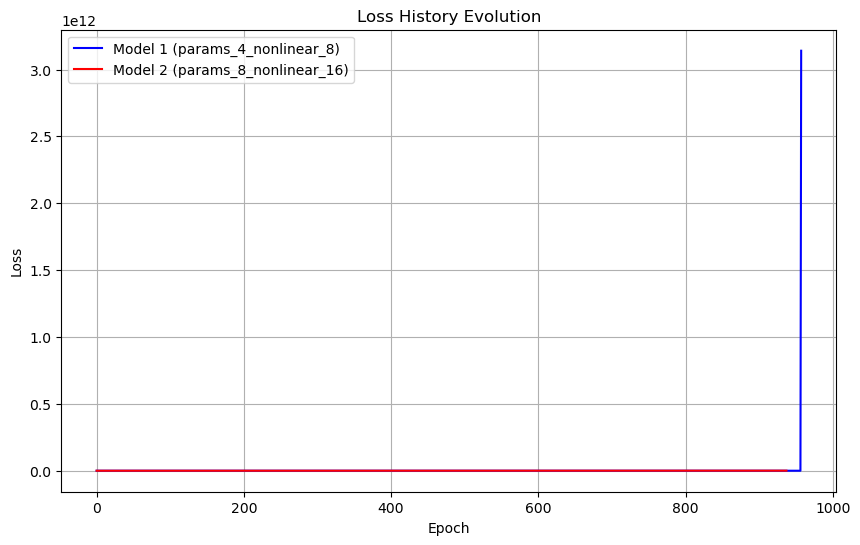

In [25]:
import matplotlib.pyplot as plt

# Extract loss_history from data_1 and data_2
loss_1 = data_1['loss_history']
loss_2 = data_2['loss_history']

# Plot the loss evolution
plt.figure(figsize=(10, 6))
plt.plot(loss_1, label='Model 1 (params_4_nonlinear_8)', color='blue')
plt.plot(loss_2, label='Model 2 (params_8_nonlinear_16)', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss History Evolution')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Extract loss_history from data_1 and data_2
loss_1 = data_1['loss_history']
loss_2 = data_2['loss_history']

# Plot the loss evolution
plt.figure(figsize=(10, 6))
plt.plot(loss_1, label='Model 1 (params_4_nonlinear_8)', color='blue')
plt.plot(loss_2, label='Model 2 (params_8_nonlinear_16)', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss History Evolution')
plt.legend()
plt.grid(True)
plt.show()

['loss_history',
 'test_loss_history',
 'train_task_accuracies',
 'test_task_accuracies']

In [ ]:
import os
from pathlib import Path

# Define the parameters from the loop
seeds = [0]
nonlinear_units_list = [1, 2, 3, 4, 5, 6, 8, 16]
hidden_sizes = [32]
num_individual_params_list = [1, 2, 3, 4, 8, 11, 12]
# Sort missing_folders by num_individual_params then nonlinear_units
missing_folders = sorted(missing_folders, key=lambda x: (int(x.split('_')[3]), int(x.split('_')[5])))
# The path for seed_0
path_seed_0 = r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\results_cluster\second_experiment\second_experiment\hidden_32\seed_0"

# Generate all expected folder names for seed_0
expected_folders = set()
for hidden_size in hidden_sizes:
    for num_params in num_individual_params_list:
        for nonlinear in nonlinear_units_list:
            folder_name = f"tasks_11_params_{num_params}_nonlinear_{nonlinear}"
            expected_folders.add(folder_name)

# Get the actual folders present in seed_0
actual_folders = set()
seed_0_path = Path(path_seed_0)
if seed_0_path.exists():
    for item in seed_0_path.iterdir():
        if item.is_dir() and item.name.startswith("tasks_11_params_"):
            actual_folders.add(item.name)

# Find missing folders
missing_folders = expected_folders - actual_folders

print(f"Total expected folders for seed_0: {len(expected_folders)}")
print(f"Total actual folders in seed_0: {len(actual_folders)}")
print(f"Missing folders in seed_0: {len(missing_folders)}")
if missing_folders:
    print("Missing combinations:")
    for folder in sorted(missing_folders):
        print(f"  {folder}")
else:
    print("No missing combinations.")

Total expected folders for seed_0: 56
Total actual folders in seed_0: 53
Missing folders in seed_0: 3
Missing combinations:
  tasks_11_params_3_nonlinear_16
  tasks_11_params_4_nonlinear_16
  tasks_11_params_8_nonlinear_16
No missing combinations.


Loaded 119 experiments from hidden_64 (seeds [0, 4])

Top 5 combinations for hidden_64:
  1. Nonlinear Units=5, Num Individual Params=8, Best Avg Test Accuracy=0.8887
  2. Nonlinear Units=5, Num Individual Params=11, Best Avg Test Accuracy=0.8624
  3. Nonlinear Units=2, Num Individual Params=8, Best Avg Test Accuracy=0.8574
  4. Nonlinear Units=3, Num Individual Params=11, Best Avg Test Accuracy=0.8566
  5. Nonlinear Units=6, Num Individual Params=11, Best Avg Test Accuracy=0.8557

Best combination for hidden_64:
  Nonlinear Units: 5
  Num Individual Params: 8
  Best Avg Test Accuracy: 0.8887


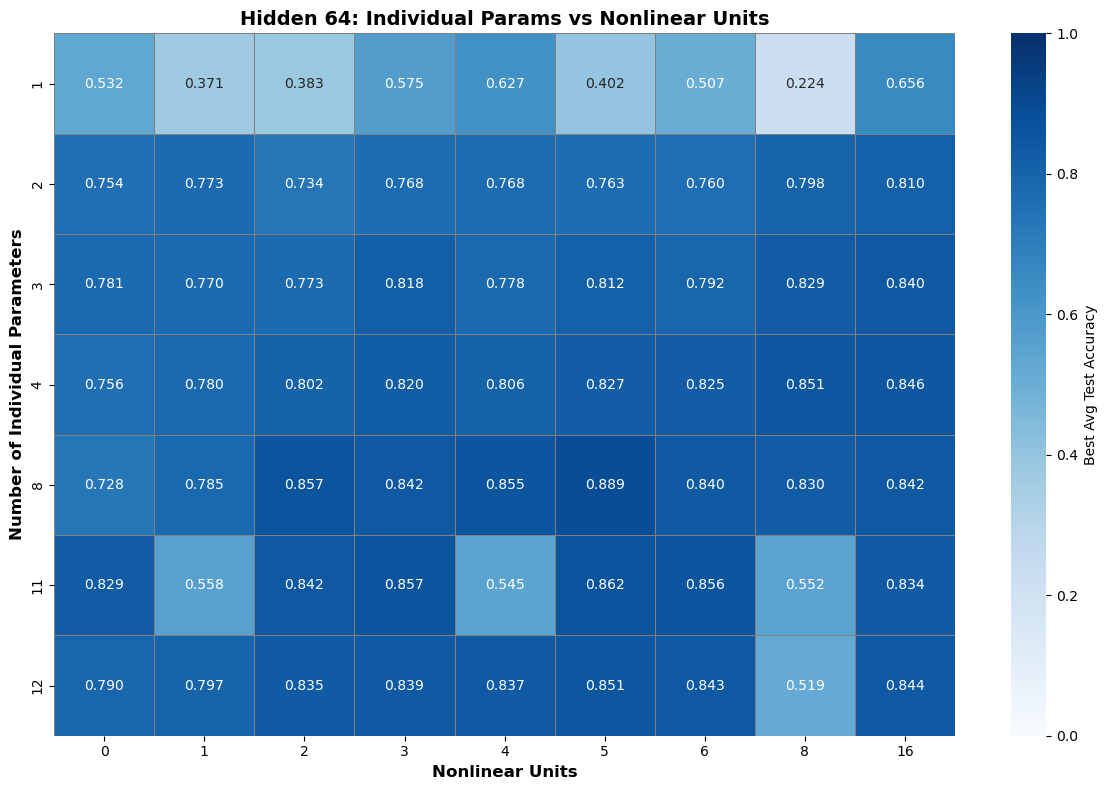

Loaded 56 experiments from hidden_100 (seeds [0, 4])

Top 5 combinations for hidden_100:
  1. Nonlinear Units=6, Num Individual Params=8, Best Avg Test Accuracy=0.8716
  2. Nonlinear Units=6, Num Individual Params=3, Best Avg Test Accuracy=0.8670
  3. Nonlinear Units=4, Num Individual Params=4, Best Avg Test Accuracy=0.8642
  4. Nonlinear Units=8, Num Individual Params=4, Best Avg Test Accuracy=0.8636
  5. Nonlinear Units=16, Num Individual Params=4, Best Avg Test Accuracy=0.8636

Best combination for hidden_100:
  Nonlinear Units: 6
  Num Individual Params: 8
  Best Avg Test Accuracy: 0.8716


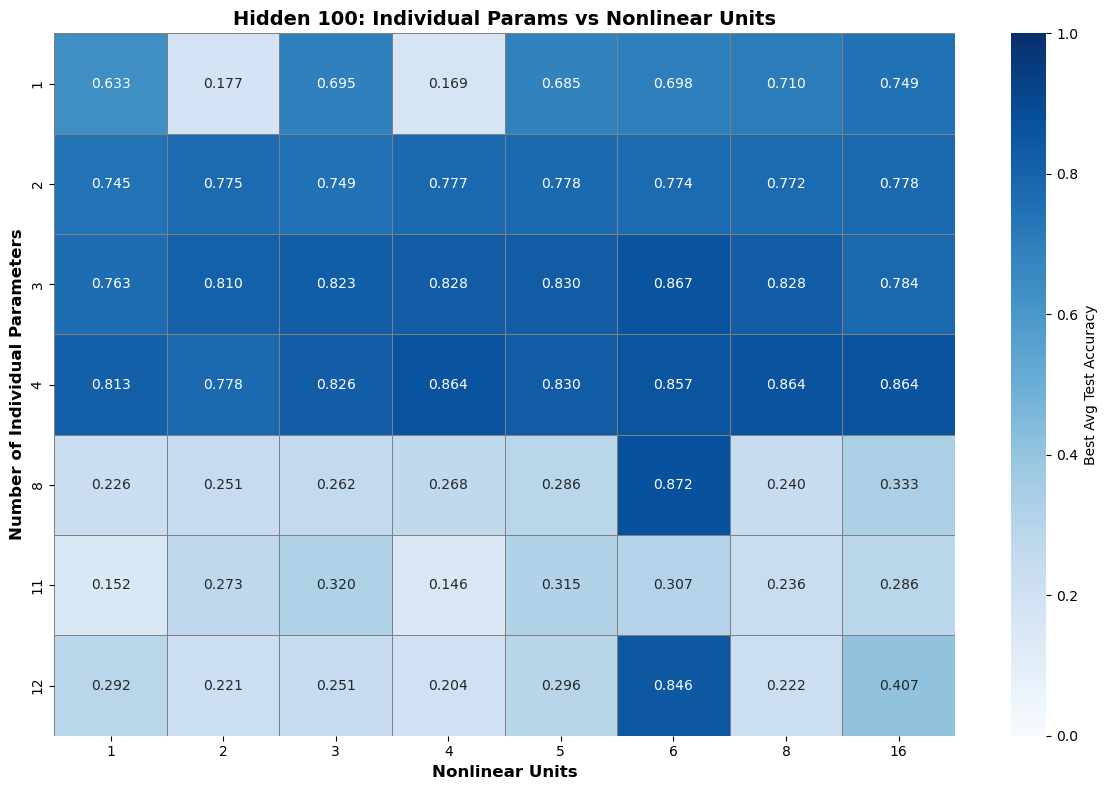

In [10]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import re

# Settings for new experiments
hidden_sizes = [64, 100]
seeds = [0, 4]
base_root = Path(r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\experiments")

def load_hidden_data(hidden_size):
    all_data = []
    for seed in seeds:
        base_path = base_root / f"hidden_{hidden_size}" / f"seed_{seed}"
        if not base_path.exists():
            print(f"Warning: {base_path} does not exist")
            continue
        for task_dir in sorted(base_path.glob("tasks_*_params_*")):
            if not task_dir.is_dir():
                continue
            metadata_path = task_dir / "metadata.json"
            if not metadata_path.exists():
                continue
            with open(metadata_path, 'r') as f:
                metadata = json.load(f)
            best_avg_acc = metadata.get("best_avg_test_accuracy")
            nonlinear_units = metadata.get("nonlinear_units")
            num_params = metadata.get("num_individual_params")
            if best_avg_acc is not None and nonlinear_units is not None and num_params is not None:
                all_data.append({
                    'Num Individual Params': num_params,
                    'Nonlinear Units': nonlinear_units,
                    'Best Avg Test Accuracy': best_avg_acc,
                })
    return pd.DataFrame(all_data)

for hidden_size in hidden_sizes:
    df = load_hidden_data(hidden_size)
    print(f"Loaded {len(df)} experiments from hidden_{hidden_size} (seeds {seeds})")
    if df.empty:
        print(f"No data for hidden_{hidden_size}")
        continue
    # Average across seeds for each (num_params, nonlinear_units) combination
    df_avg = df.groupby(['Num Individual Params', 'Nonlinear Units'])['Best Avg Test Accuracy'].mean().reset_index()
    print(f"\nTop 5 combinations for hidden_{hidden_size}:")
    top5 = df_avg.sort_values('Best Avg Test Accuracy', ascending=False).head(5)
    for rank, row in enumerate(top5.itertuples(index=False, name='Row'), start=1):
        print(
            f"  {rank}. Nonlinear Units={row._1}, Num Individual Params={row._0}, "
            f"Best Avg Test Accuracy={row._2:.4f}"
        )
    # Pivot data for heatmap: rows = num_params, columns = nonlinear_units
    heatmap_pivot = df_avg.pivot_table(
        index='Num Individual Params',
        columns='Nonlinear Units',
        values='Best Avg Test Accuracy',
        aggfunc='mean'
)
    heatmap_pivot = heatmap_pivot.sort_index(axis=0)
    heatmap_pivot = heatmap_pivot.sort_index(axis=1)
    # Find the best combination
    max_idx = heatmap_pivot.stack().idxmax()
    max_params, max_nonlinear = max_idx
    max_accuracy = heatmap_pivot.loc[max_params, max_nonlinear]
    print(f"\nBest combination for hidden_{hidden_size}:")
    print(f"  Nonlinear Units: {max_nonlinear}")
    print(f"  Num Individual Params: {max_params}")
    print(f"  Best Avg Test Accuracy: {max_accuracy:.4f}")
    # Create heatmap
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(
        heatmap_pivot,
        annot=True,
        fmt='.3f',
        cmap='Blues',
        cbar_kws={'label': 'Best Avg Test Accuracy'},
        ax=ax,
        vmin=0.0,
        vmax=1.0,
        linewidths=0.5,
        linecolor='gray'
)
    ax.set_xlabel('Nonlinear Units', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Individual Parameters', fontsize=12, fontweight='bold')
    ax.set_title(f"Hidden {hidden_size}: Individual Params vs Nonlinear Units",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

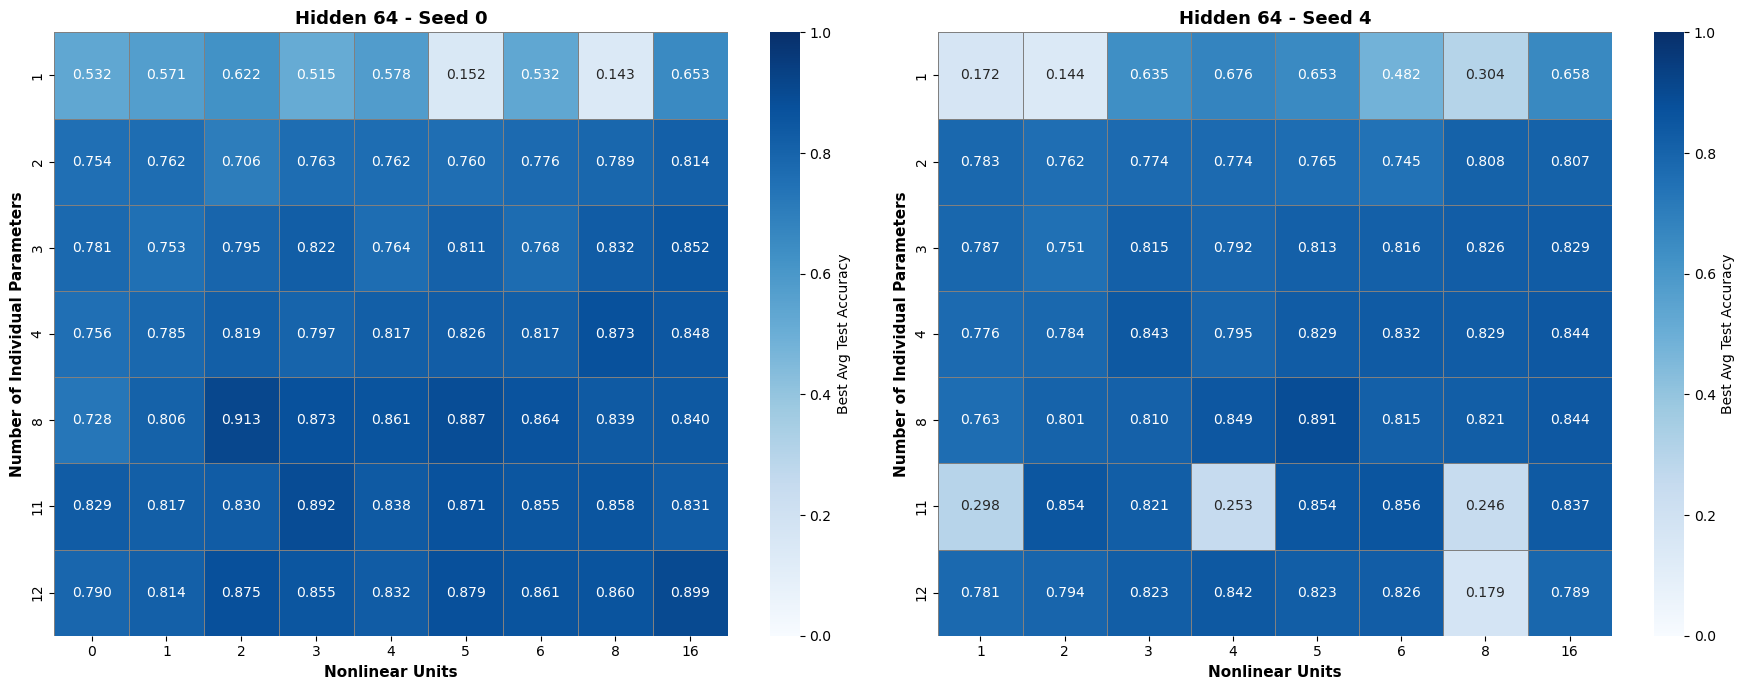

In [11]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Show seed-specific values for hidden_64 (no averaging)
hidden_size = 64
seeds = [0, 4]
base_root = Path(r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\experiments")

def load_seed_data(seed):
    all_data = []
    base_path = base_root / f"hidden_{hidden_size}" / f"seed_{seed}"
    if not base_path.exists():
        print(f"Warning: {base_path} does not exist")
        return pd.DataFrame()
    for task_dir in sorted(base_path.glob("tasks_*_params_*")):
        if not task_dir.is_dir():
            continue
        metadata_path = task_dir / "metadata.json"
        if not metadata_path.exists():
            continue
        with open(metadata_path, 'r') as f:
            metadata = json.load(f)
        best_avg_acc = metadata.get("best_avg_test_accuracy")
        nonlinear_units = metadata.get("nonlinear_units")
        num_params = metadata.get("num_individual_params")
        if best_avg_acc is not None and nonlinear_units is not None and num_params is not None:
            all_data.append({
                'Num Individual Params': num_params,
                'Nonlinear Units': nonlinear_units,
                'Best Avg Test Accuracy': best_avg_acc,
            })
    return pd.DataFrame(all_data)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, seed in zip(axes, seeds):
    df_seed = load_seed_data(seed)
    if df_seed.empty:
        ax.set_title(f"Hidden {hidden_size} - Seed {seed} (no data)")
        ax.axis('off')
        continue
    heatmap_pivot = df_seed.pivot_table(
        index='Num Individual Params',
        columns='Nonlinear Units',
        values='Best Avg Test Accuracy',
        aggfunc='mean'
    )
    heatmap_pivot = heatmap_pivot.sort_index(axis=0)
    heatmap_pivot = heatmap_pivot.sort_index(axis=1)
    sns.heatmap(
        heatmap_pivot,
        annot=True,
        fmt='.3f',
        cmap='Blues',
        cbar_kws={'label': 'Best Avg Test Accuracy'},
        ax=ax,
        vmin=0.0,
        vmax=1.0,
        linewidths=0.5,
        linecolor='gray'
    )
    ax.set_xlabel('Nonlinear Units', fontsize=11, fontweight='bold')
    ax.set_ylabel('Number of Individual Parameters', fontsize=11, fontweight='bold')
    ax.set_title(f"Hidden {hidden_size} - Seed {seed}", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

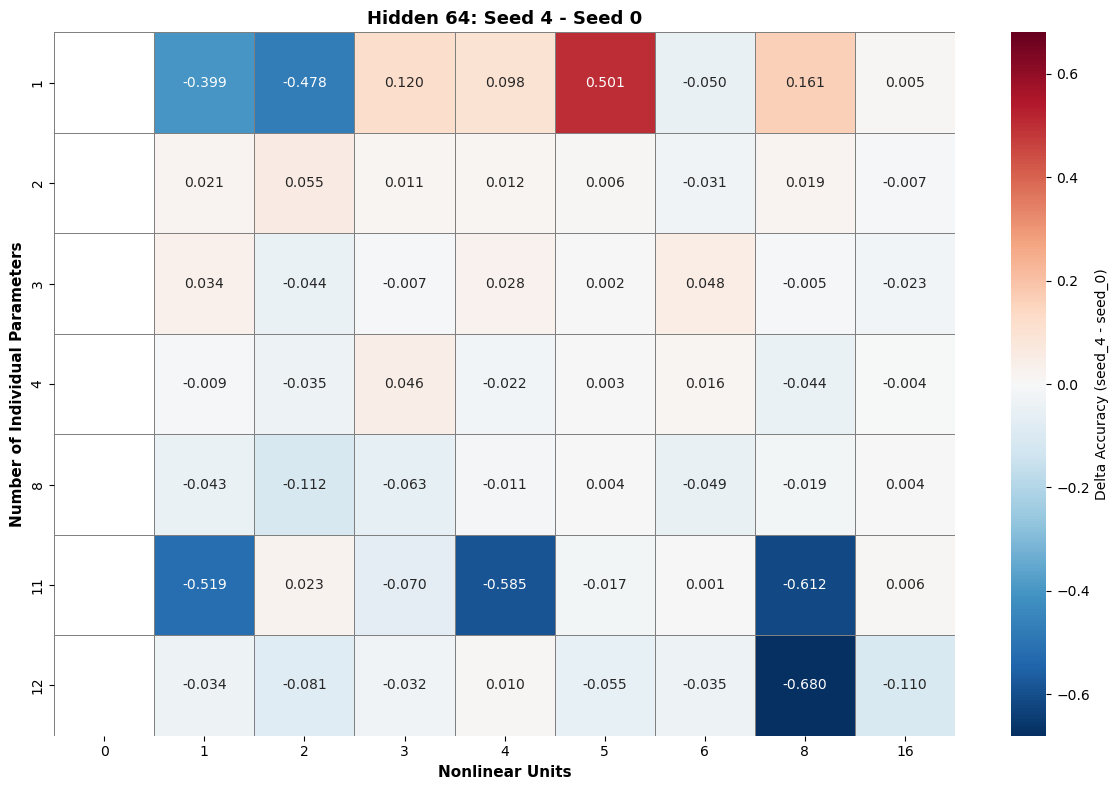

In [13]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Difference heatmap: seed_4 minus seed_0 (hidden_64)
hidden_size = 64
seed_a = 0
seed_b = 4
base_root = Path(r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\experiments")

def load_seed_data(seed):
    all_data = []
    base_path = base_root / f"hidden_{hidden_size}" / f"seed_{seed}"
    if not base_path.exists():
        print(f"Warning: {base_path} does not exist")
        return pd.DataFrame()
    for task_dir in sorted(base_path.glob("tasks_*_params_*")):
        if not task_dir.is_dir():
            continue
        metadata_path = task_dir / "metadata.json"
        if not metadata_path.exists():
            continue
        with open(metadata_path, 'r') as f:
            metadata = json.load(f)
        best_avg_acc = metadata.get("best_avg_test_accuracy")
        nonlinear_units = metadata.get("nonlinear_units")
        num_params = metadata.get("num_individual_params")
        if best_avg_acc is not None and nonlinear_units is not None and num_params is not None:
            all_data.append({
                'Num Individual Params': num_params,
                'Nonlinear Units': nonlinear_units,
                'Best Avg Test Accuracy': best_avg_acc,
            })
    return pd.DataFrame(all_data)

df_a = load_seed_data(seed_a)
df_b = load_seed_data(seed_b)

if df_a.empty or df_b.empty:
    print(f"Missing data for seeds {seed_a} or {seed_b}")
else:
    pivot_a = df_a.pivot_table(
        index='Num Individual Params',
        columns='Nonlinear Units',
        values='Best Avg Test Accuracy',
        aggfunc='mean'
    )
    pivot_b = df_b.pivot_table(
        index='Num Individual Params',
        columns='Nonlinear Units',
        values='Best Avg Test Accuracy',
        aggfunc='mean'
    )
    pivot_a = pivot_a.sort_index(axis=0).sort_index(axis=1)
    pivot_b = pivot_b.sort_index(axis=0).sort_index(axis=1)
    diff = pivot_b - pivot_a
    max_abs = diff.abs().max().max()
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(
        diff,
        annot=True,
        fmt='.3f',
        cmap='RdBu_r',
        center=0,
        vmin=-max_abs,
        vmax=max_abs,
        cbar_kws={'label': f'Delta Accuracy (seed_{seed_b} - seed_{seed_a})'},
        ax=ax,
        linewidths=0.5,
        linecolor='gray'
    )
    ax.set_xlabel('Nonlinear Units', fontsize=11, fontweight='bold')
    ax.set_ylabel('Number of Individual Parameters', fontsize=11, fontweight='bold')
    ax.set_title(f"Hidden {hidden_size}: Seed {seed_b} - Seed {seed_a}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

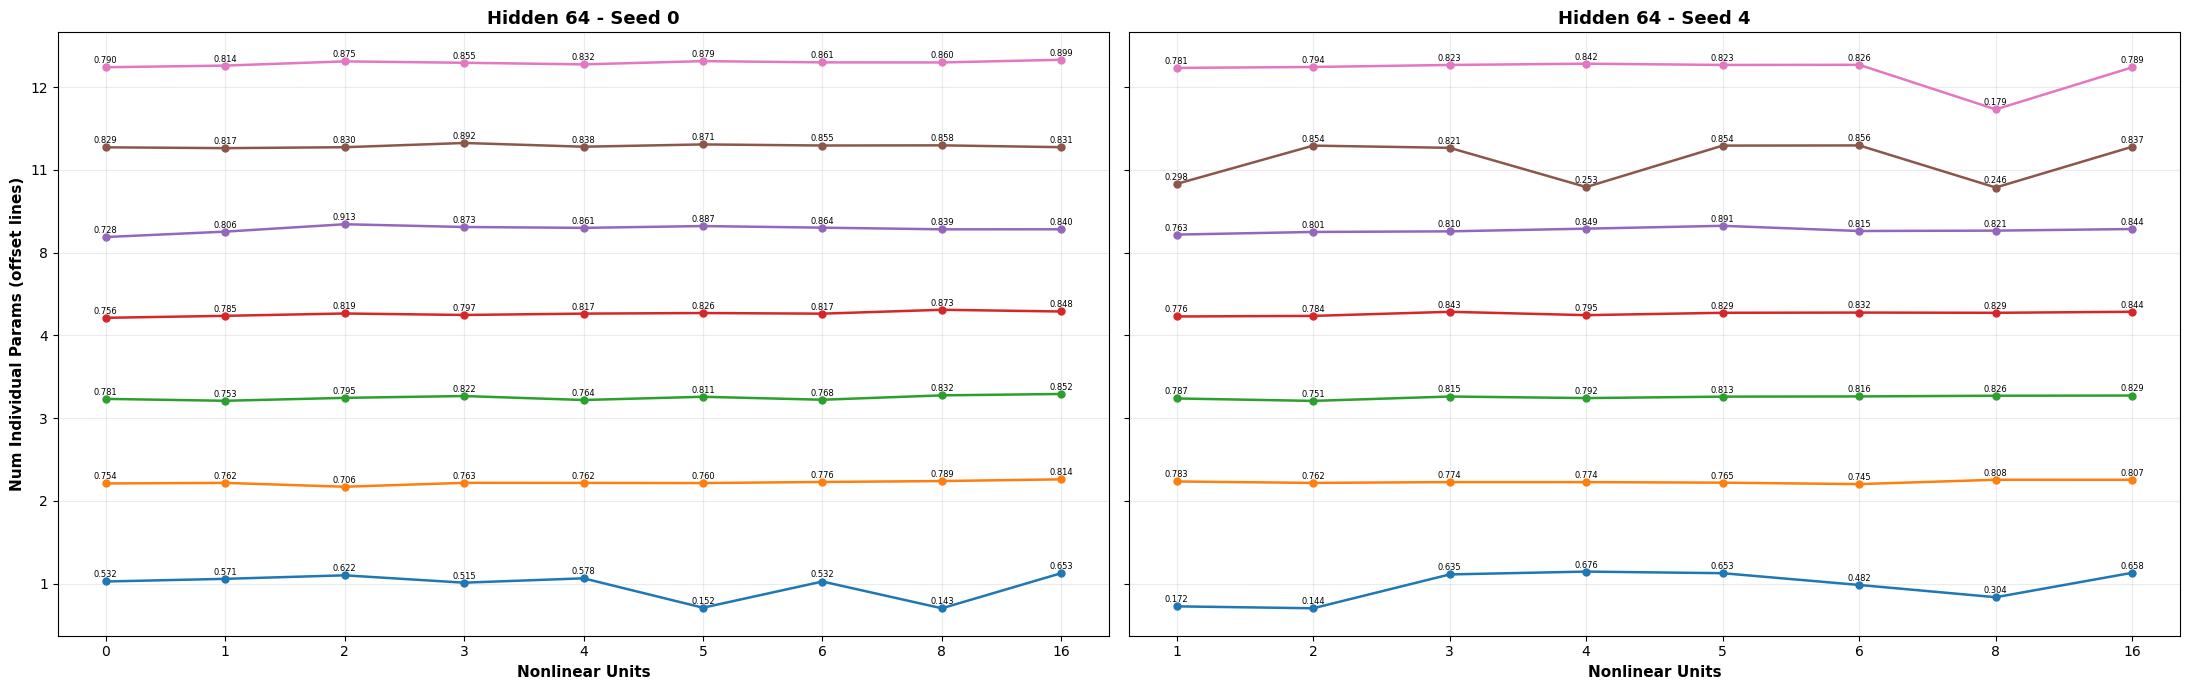

In [19]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Offset line plot per seed (hidden_64)
hidden_size = 64
seeds = [0, 4]
base_root = Path(r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\experiments")

def load_seed_data(seed):
    all_data = []
    base_path = base_root / f"hidden_{hidden_size}" / f"seed_{seed}"
    if not base_path.exists():
        print(f"Warning: {base_path} does not exist")
        return pd.DataFrame()
    for task_dir in sorted(base_path.glob("tasks_*_params_*")):
        if not task_dir.is_dir():
            continue
        metadata_path = task_dir / "metadata.json"
        if not metadata_path.exists():
            continue
        with open(metadata_path, 'r') as f:
            metadata = json.load(f)
        best_avg_acc = metadata.get("best_avg_test_accuracy")
        nonlinear_units = metadata.get("nonlinear_units")
        num_params = metadata.get("num_individual_params")
        if best_avg_acc is not None and nonlinear_units is not None and num_params is not None:
            all_data.append({
                'Num Individual Params': num_params,
                'Nonlinear Units': nonlinear_units,
                'Best Avg Test Accuracy': best_avg_acc,
            })
    return pd.DataFrame(all_data)

fig, axes = plt.subplots(1, len(seeds), figsize=(22, 7), sharey=True)
if len(seeds) == 1:
    axes = [axes]

for ax, seed in zip(axes, seeds):
    df_seed = load_seed_data(seed)
    if df_seed.empty:
        ax.set_title(f"Hidden {hidden_size} - Seed {seed} (no data)")
        ax.axis('off')
        continue
    # Build pivot with nonlinear units on x-axis
    pivot = df_seed.pivot_table(
        index='Num Individual Params',
        columns='Nonlinear Units',
        values='Best Avg Test Accuracy',
        aggfunc='mean'
    )
    pivot = pivot.sort_index(axis=0).sort_index(axis=1)
    pivot = pivot.loc[:, [c for c in pivot.columns if c not in (10, 12, 14)]]
    num_params_list = list(pivot.index)
    nonlinear_list = list(pivot.columns)
    x_pos = np.arange(len(nonlinear_list))
    # Plot offset lines per num_params
    gap = 1.2
    for i, num_params in enumerate(num_params_list):
        y = pivot.loc[num_params].values
        offset = i * gap
        ax.plot(x_pos, y + offset, marker='o', linewidth=1.8, markersize=5)
        for xi, yi, val in zip(x_pos, y + offset, y):
            ax.text(xi, yi + 0.03, f"{val:.3f}", fontsize=6, ha='center', va='bottom')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(n) for n in nonlinear_list])
    # Y ticks centered per param group
    y_ticks = [i * gap + 0.5 for i in range(len(num_params_list))]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([str(n) for n in num_params_list])
    ax.set_xlabel('Nonlinear Units', fontsize=11, fontweight='bold')
    ax.set_title(f"Hidden {hidden_size} - Seed {seed}", fontsize=13, fontweight='bold')
    ax.grid(alpha=0.25)

axes[0].set_ylabel('Num Individual Params (offset lines)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [47]:
data = np.load(r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\experiments\hidden_64\seed_0\tasks_17_params_8_nonlinear_2\results.npz", allow_pickle=True)
metadata = json.load(open(r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\experiments\hidden_64\seed_0\tasks_17_params_8_nonlinear_2\metadata.json"))
best_idx = np.where(data['test_loss_history'] == metadata["best_test_loss"])[0][0]
raw = data["test_task_accuracies"].item()
result = {k: v[best_idx] for k, v in raw.items()}



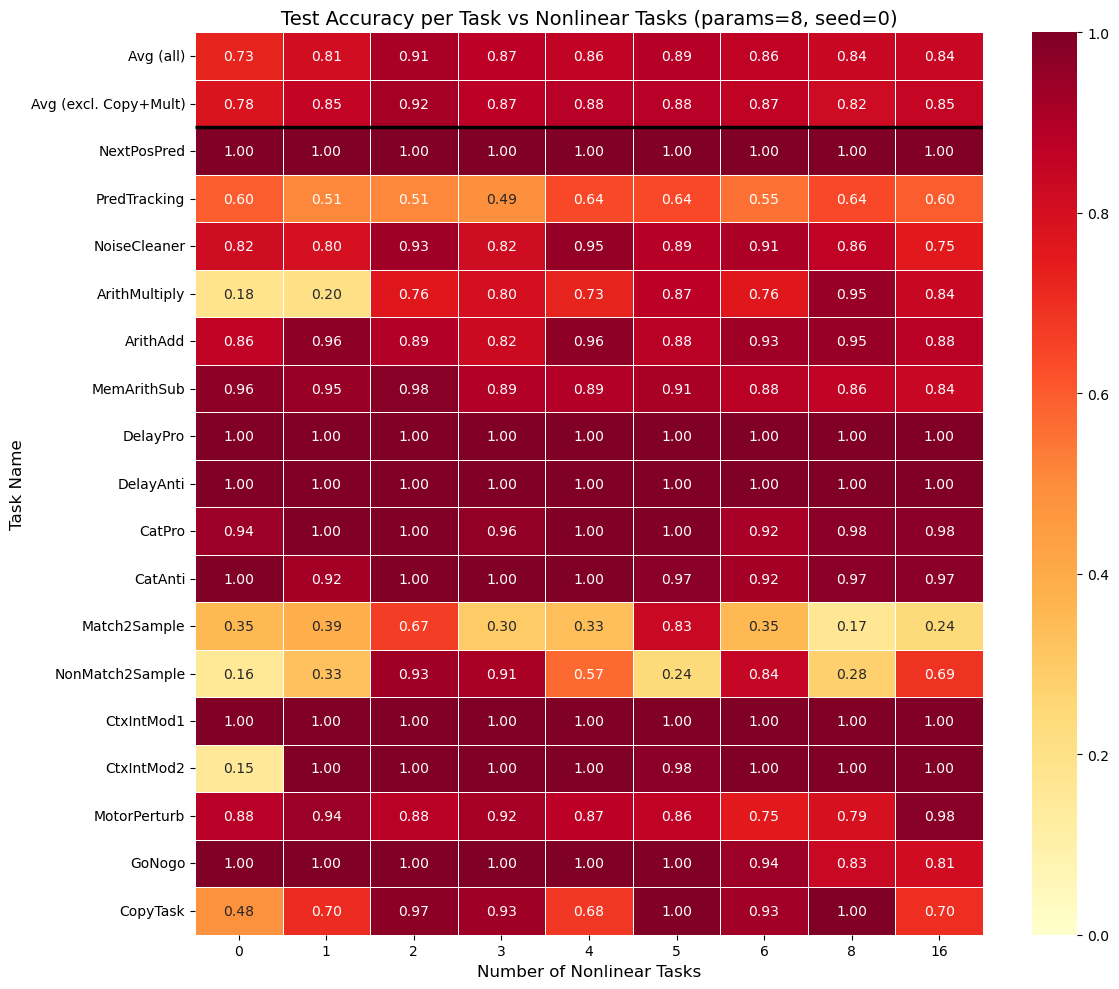

In [67]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

base_dir = Path(r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\experiments\hidden_64\seed_0")

# Find all params_8 folders and extract nonlinear values
folders = sorted(base_dir.glob("tasks_17_params_8_nonlinear_*"))
nonlinear_values = []
all_accuracies = {}

for folder in folders:
    nl_val = int(folder.name.split("nonlinear_")[-1])
    nonlinear_values.append(nl_val)
    
    data = np.load(folder / "results.npz", allow_pickle=True)
    metadata = json.load(open(folder / "metadata.json"))
    
    best_idx = np.where(data['test_loss_history'] == metadata["best_test_loss"])[0][0]
    raw = data["test_task_accuracies"].item()
    task_names = metadata["task_names"]
    
    for k, v in raw.items():
        task_name = task_names[k]
        if task_name not in all_accuracies:
            all_accuracies[task_name] = {}
        all_accuracies[task_name][nl_val] = v[best_idx]

nonlinear_values = sorted(nonlinear_values)
task_names_ordered = list(all_accuracies.keys())

# Build DataFrame for heatmap
heatmap_data = pd.DataFrame(index=task_names_ordered, columns=nonlinear_values, dtype=float)
for task in task_names_ordered:
    for nl in nonlinear_values:
        heatmap_data.loc[task, nl] = all_accuracies[task].get(nl, np.nan)

# Average over all tasks
avg_all = heatmap_data.astype(float).mean(axis=0)
# Average excluding CopyTask and ArithMultiply
excluded = ["CopyTask", "ArithMultiply"]
filtered_tasks = [t for t in task_names_ordered if t not in excluded]
avg_filtered = heatmap_data.loc[filtered_tasks].astype(float).mean(axis=0)

heatmap_data.loc["Avg (all)"] = avg_all
heatmap_data.loc["Avg (excl. Copy+Mult)"] = avg_filtered

# Reorder so averages are on top
heatmap_data = heatmap_data.loc[["Avg (all)", "Avg (excl. Copy+Mult)"] + task_names_ordered]

plt.figure(figsize=(12, 10))
ax = sns.heatmap(heatmap_data.astype(float), annot=True, fmt=".2f", cmap="YlOrRd", 
                 vmin=0, vmax=1, linewidths=0.5)
# Thicker line to separate averages from task rows
ax.hlines([2], *ax.get_xlim(), colors='black', linewidths=2.5)
plt.xlabel("Number of Nonlinear Tasks", fontsize=12)
plt.ylabel("Task Name", fontsize=12)
plt.title("Test Accuracy per Task vs Nonlinear Tasks (params=8, seed=0)", fontsize=14)
plt.tight_layout()
plt.show()

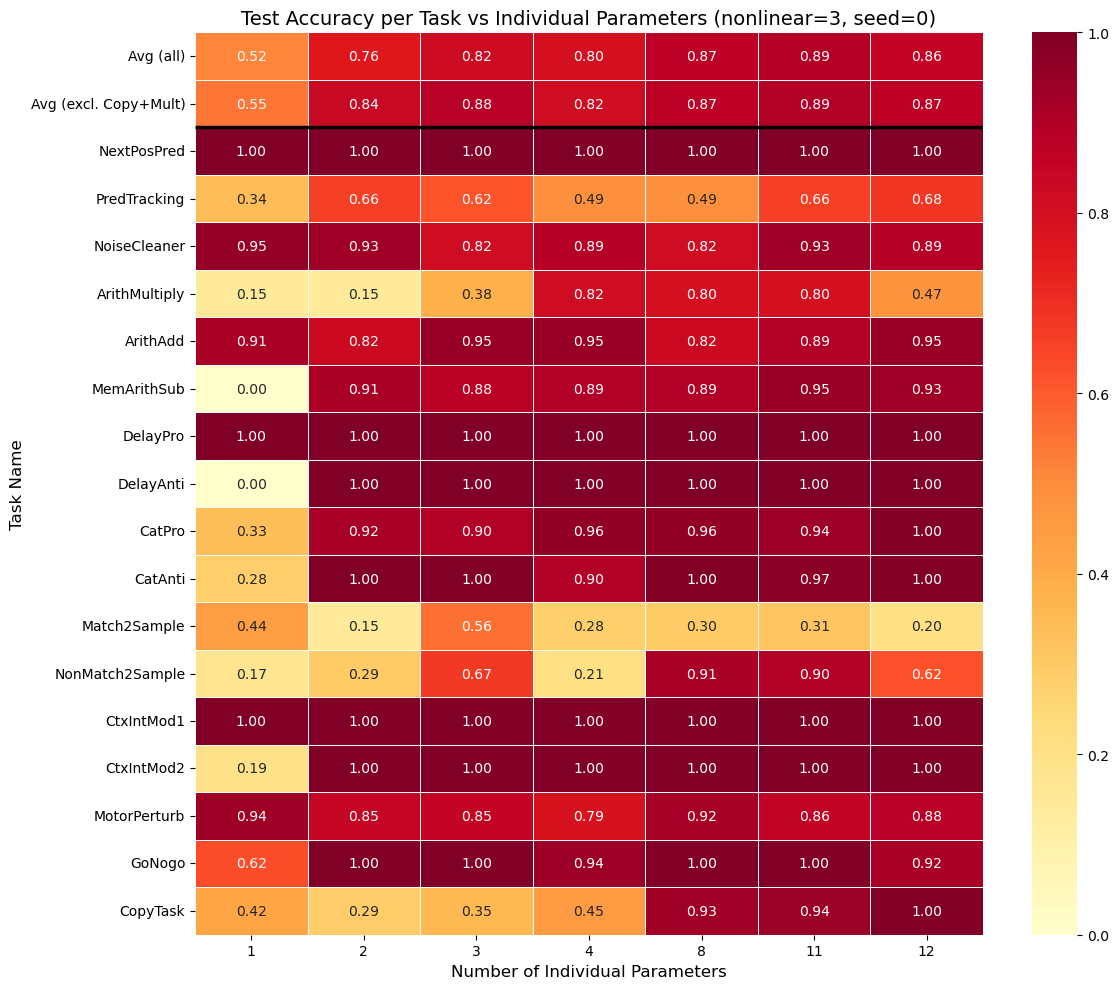

In [66]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

base_dir = Path(r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\experiments\hidden_64\seed_0")

# Find all nonlinear_3 folders and extract params values
folders = sorted(base_dir.glob("tasks_17_params_*_nonlinear_3"))
params_values = []
all_accuracies = {}

for folder in folders:
    params_val = int(folder.name.split("params_")[1].split("_nonlinear")[0])
    params_values.append(params_val)
    
    data = np.load(folder / "results.npz", allow_pickle=True)
    metadata = json.load(open(folder / "metadata.json"))
    
    best_idx = np.where(data['test_loss_history'] == metadata["best_test_loss"])[0][0]
    raw = data["test_task_accuracies"].item()
    task_names = metadata["task_names"]
    
    for k, v in raw.items():
        task_name = task_names[k]
        if task_name not in all_accuracies:
            all_accuracies[task_name] = {}
        all_accuracies[task_name][params_val] = v[best_idx]

params_values = sorted(params_values)
task_names_ordered = list(all_accuracies.keys())

# Build DataFrame for heatmap
heatmap_data = pd.DataFrame(index=task_names_ordered, columns=params_values, dtype=float)
for task in task_names_ordered:
    for p in params_values:
        heatmap_data.loc[task, p] = all_accuracies[task].get(p, np.nan)

# Average over all tasks
avg_all = heatmap_data.astype(float).mean(axis=0)
# Average excluding CopyTask and ArithMultiply
excluded = ["CopyTask", "ArithMultiply"]
filtered_tasks = [t for t in task_names_ordered if t not in excluded]
avg_filtered = heatmap_data.loc[filtered_tasks].astype(float).mean(axis=0)

heatmap_data.loc["Avg (all)"] = avg_all
heatmap_data.loc["Avg (excl. Copy+Mult)"] = avg_filtered

# Reorder so averages are on top
heatmap_data = heatmap_data.loc[["Avg (all)", "Avg (excl. Copy+Mult)"] + task_names_ordered]

plt.figure(figsize=(12, 10))
ax = sns.heatmap(heatmap_data.astype(float), annot=True, fmt=".2f", cmap="YlOrRd", 
                 vmin=0, vmax=1, linewidths=0.5)
# Thicker line to separate averages from task rows
ax.hlines([2], *ax.get_xlim(), colors='black', linewidths=2.5)
plt.xlabel("Number of Individual Parameters", fontsize=12)
plt.ylabel("Task Name", fontsize=12)
plt.title("Test Accuracy per Task vs Individual Parameters (nonlinear=3, seed=0)", fontsize=14)
plt.tight_layout()
plt.show()

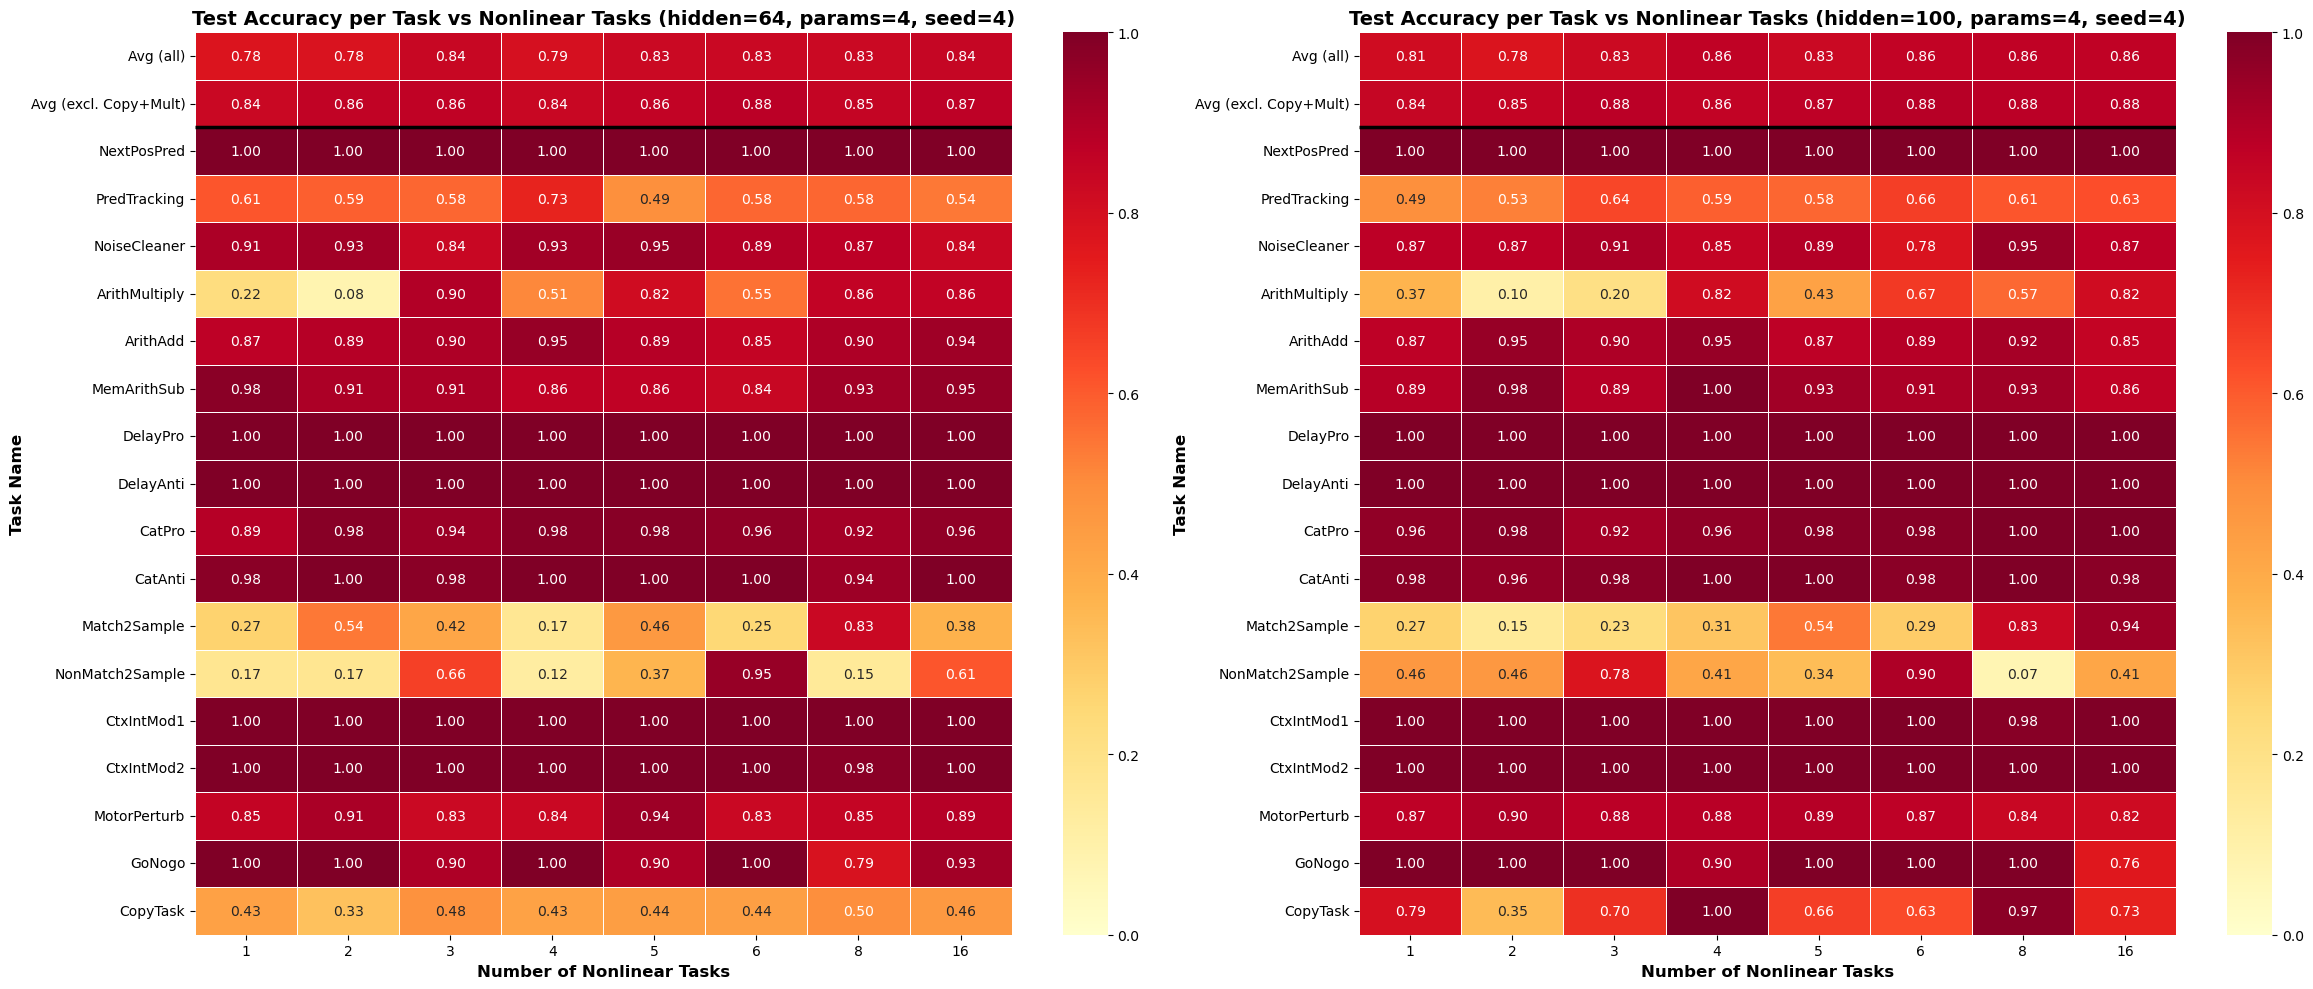

In [72]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

base_root = Path(r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\experiments")

# Create figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# List of hidden size configurations to plot
hidden_sizes = [64, 100]
params_val = 4
seed_val = 4

for idx, (ax, hidden_size) in enumerate(zip(axes, hidden_sizes)):
    # Build the base directory for this hidden_size
    base_dir = base_root / f"hidden_{hidden_size}" / f"seed_{seed_val}"
    
    # Find all folders with params=4 and varying nonlinear values
    folders = sorted(base_dir.glob(f"tasks_17_params_{params_val}_nonlinear_*"))
    nonlinear_values = []
    all_accuracies = {}
    
    for folder in folders:
        nl_val = int(folder.name.split("nonlinear_")[-1])
        nonlinear_values.append(nl_val)
        
        data = np.load(folder / "results.npz", allow_pickle=True)
        metadata = json.load(open(folder / "metadata.json"))
        
        best_idx = np.where(data['test_loss_history'] == metadata["best_test_loss"])[0][0]
        raw = data["test_task_accuracies"].item()
        task_names = metadata["task_names"]
        
        for k, v in raw.items():
            task_name = task_names[k]
            if task_name not in all_accuracies:
                all_accuracies[task_name] = {}
            all_accuracies[task_name][nl_val] = v[best_idx]
    
    nonlinear_values = sorted(nonlinear_values)
    task_names_ordered = list(all_accuracies.keys())
    
    # Build DataFrame for heatmap
    heatmap_data = pd.DataFrame(index=task_names_ordered, columns=nonlinear_values, dtype=float)
    for task in task_names_ordered:
        for nl in nonlinear_values:
            heatmap_data.loc[task, nl] = all_accuracies[task].get(nl, np.nan)
    
    # Average over all tasks
    avg_all = heatmap_data.astype(float).mean(axis=0)
    # Average excluding CopyTask and ArithMultiply
    excluded = ["CopyTask", "ArithMultiply"]
    filtered_tasks = [t for t in task_names_ordered if t not in excluded]
    avg_filtered = heatmap_data.loc[filtered_tasks].astype(float).mean(axis=0)
    
    heatmap_data.loc["Avg (all)"] = avg_all
    heatmap_data.loc["Avg (excl. Copy+Mult)"] = avg_filtered
    
    # Reorder so averages are on top
    heatmap_data = heatmap_data.loc[["Avg (all)", "Avg (excl. Copy+Mult)"] + task_names_ordered]
    
    # Create heatmap on the current axis
    sns.heatmap(heatmap_data.astype(float), annot=True, fmt=".2f", cmap="YlOrRd", 
                vmin=0, vmax=1, linewidths=0.5, ax=ax)
    
    # Thicker line to separate averages from task rows
    ax.hlines([2], *ax.get_xlim(), colors='black', linewidths=2.5)
    ax.set_xlabel("Number of Nonlinear Tasks", fontsize=12, fontweight='bold')
    ax.set_ylabel("Task Name", fontsize=12, fontweight='bold')
    ax.set_title(f"Test Accuracy per Task vs Nonlinear Tasks (hidden={hidden_size}, params={params_val}, seed={seed_val})", 
                 fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

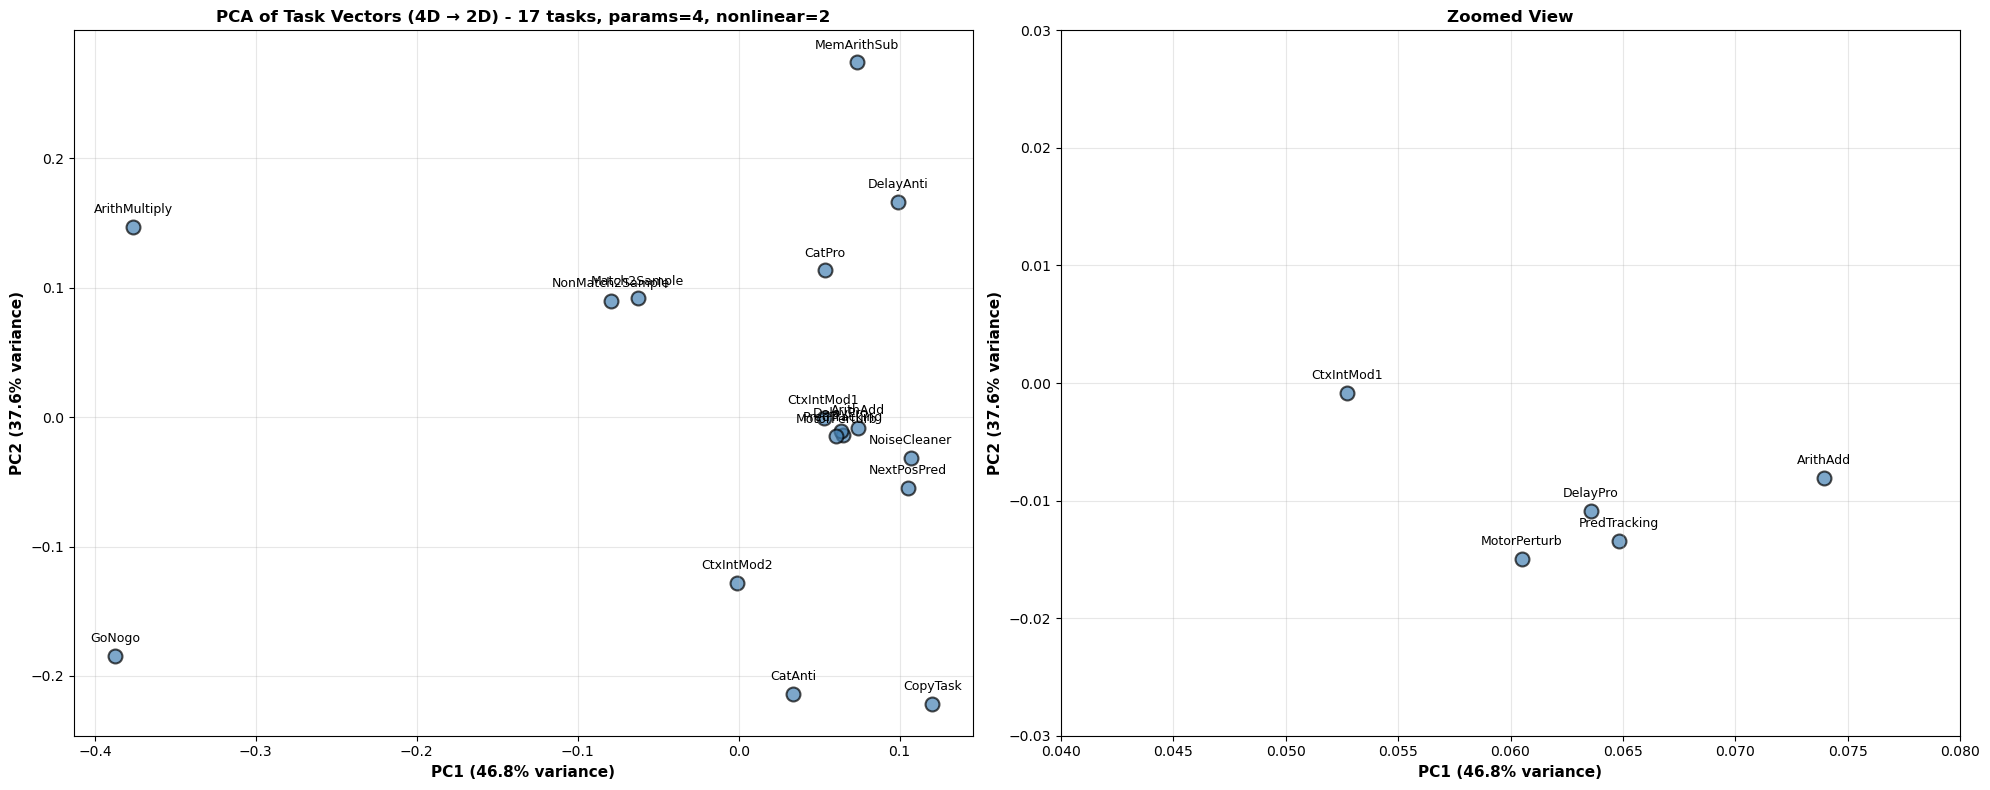

Task Vectors shape: (17, 4)
Total variance explained: 84.39%


In [5]:
from sklearn.decomposition import PCA
import torch
import matplotlib.pyplot as plt

# Load model
model = torch.load(r"C:\Users\garcias\Documents\Projects\Linear_Nonlinear_Memory\hierachical_model_task\results\experiments\hidden_64\seed_0\tasks_17_params_4_nonlinear_2\model.pt")

# Task order (17 tasks)
task_order = ["NextPosPred", "PredTracking", "NoiseCleaner", "ArithMultiply", "ArithAdd", "MemArithSub",
              "DelayPro", "DelayAnti", "CatPro", "CatAnti", "Match2Sample", "NonMatch2Sample",
              "CtxIntMod1", "CtxIntMod2", "MotorPerturb", "GoNogo", "CopyTask"]

# PCA of Task Vectors
task_vectors = model["p_vector"].cpu().detach().numpy() if isinstance(model["p_vector"], torch.Tensor) else model["p_vector"]
pca_task = PCA(n_components=2)
task_vectors_pca = pca_task.fit_transform(task_vectors)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax in axes:
    ax.scatter(task_vectors_pca[:, 0], task_vectors_pca[:, 1], s=100, alpha=0.7, color='steelblue',
               edgecolors='black', linewidth=1.5)
    for i, task in enumerate(task_order):
        ax.annotate(task, (task_vectors_pca[i, 0], task_vectors_pca[i, 1]),
                    textcoords="offset points", xytext=(0, 10),
                    ha='center', fontsize=9)
    ax.set_xlabel(f'PC1 ({pca_task.explained_variance_ratio_[0]:.1%} variance)', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'PC2 ({pca_task.explained_variance_ratio_[1]:.1%} variance)', fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)

axes[0].set_title(f'PCA of Task Vectors ({task_vectors.shape[1]}D \u2192 2D) - 17 tasks, params=4, nonlinear=2', fontsize=12, fontweight='bold')
axes[1].set_xlim(0.04, 0.08)
axes[1].set_ylim(-0.03, 0.03)
axes[1].set_title('Zoomed View', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Task Vectors shape: {task_vectors.shape}")
print(f"Total variance explained: {sum(pca_task.explained_variance_ratio_):.2%}")